In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 50)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
# try:
#     from cellacdc import cca_functions
#     from cellacdc import myutils
# except FileNotFoundError:
#     # Check if user has developer version --> add the Cell_ACDC/cellacdc
#     # folder to path and import from thre
#     sys.path.insert(0, '../cellacdc/')
#     from cellacdc import cca_functions
#     from cellacdc import myutils

# ***Import nutrient switch data - original four strains*** 
# ***Import nutrient switch data - Cln3 deletions and MK strains***
# ***Import nutrient switch data - MK strains with deletions*** 
# ***Import steady state data*** 

In [3]:
NS_original_4strains= pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
NS_cln3dels_MKoriginals = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
NS_MKstrains_withOriginalDels = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\Cln3stabs_withMutants_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
SS_SCDnSCGE = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\steadystate_analysed_fornutswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")

C:\Users\timon\AppData\Local\Temp\ipykernel_31232\3250585671.py:1: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_original_4strains= pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\3250585671.py:2: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_cln3dels_MKoriginals = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\3250585671.py:3: DtypeWarning: Columns (343) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_MKstrains_withOriginalDels = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_

# ***update rep for MMY in the additional nutrient switch data*** 

In [4]:
#### because NS_cln3dels_MKoriginals has MMY cells with same rep, pos and Cell_ID as NS_original_4strains, edit rep column for these cells
# NS_MKstrains_withOriginalDels experiments did not have MMY 

NS_cln3dels_MKoriginals.loc[(NS_cln3dels_MKoriginals['strain'] == "MMY") & (NS_cln3dels_MKoriginals['rep'] == 1), 'rep'] = 4
NS_cln3dels_MKoriginals.loc[(NS_cln3dels_MKoriginals['strain'] == "MMY") & (NS_cln3dels_MKoriginals['rep'] == 2), 'rep'] = 5

NS_cln3dels_MKoriginals['f_pos_cell_id'] = NS_cln3dels_MKoriginals.apply(lambda x: f'{x["strain"]}_{x["position"]}_Cell_{x["Cell_ID"]}_Gen_{int(x["generation_num"])}', axis=1)
NS_cln3dels_MKoriginals['rep_str_pos_cell_id'] = NS_cln3dels_MKoriginals.apply(lambda x: f'{x["f_pos_cell_id"]}_Rep_{int(x["rep"])}', axis=1)
NS_cln3dels_MKoriginals = NS_cln3dels_MKoriginals.drop(['f_pos_cell_id'], axis=1)
NS_cln3dels_MKoriginals = NS_cln3dels_MKoriginals.rename(columns={"rep_str_pos_cell_id": "f_pos_cell_id"})


# ***because acdc output columns changed over the years, find differences between column names of different dfs and edit them*** 

In [5]:
NS_MKstrains_withOriginalDels.drop(columns =['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',  'num_objects', 'num_objects_rel',
       'will_divide', 'will_divide_rel'], inplace = True)
#print(NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns))

In [6]:
NS_cln3dels_MKoriginals.drop(columns =['bbox', 'bbox_rel', 'centroid', 'centroid_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel',
       'inertia_tensor_rel', 'label', 'label_rel', 'local_centroid',
       'local_centroid_rel', 'moments', 'moments_central',
       'moments_central_rel', 'moments_normalized', 'moments_normalized_rel',
       'moments_rel', 'time_hours', 'time_hours_rel', 'time_minutes',
       'time_minutes_rel'], inplace = True)

In [7]:
NS_MKstrains_withOriginalDels.drop(columns =['bbox', 'bbox_rel', 'centroid', 'centroid_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel',
       'inertia_tensor_rel', 'label', 'label_rel', 'local_centroid',
       'local_centroid_rel', 'moments', 'moments_central',
       'moments_central_rel', 'moments_normalized', 'moments_normalized_rel',
       'moments_rel', 'time_hours', 'time_hours_rel', 'time_minutes',
       'time_minutes_rel'], inplace = True)

In [8]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index(['does_cell_die_in_this_phase', 'vol_added_since_prev_frame_fl'], dtype='object')

In [9]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox',
       'bbox_rel', 'centroid', 'centroid_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inert

In [10]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index(['does_cell_die_in_this_phase'], dtype='object')

In [11]:
NS_original_4strains = NS_original_4strains.rename(columns={"vol_added_since_last_frame": "vol_added_since_prev_frame_fl"})
SS_SCDnSCGE = SS_SCDnSCGE.rename(columns={"Strain": "strain"})

In [12]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'num_objects',
       'num_objects_rel', 'will_divide', 'will_divide_rel'],
      dtype='object')

# ***Add 'does_cell_die_in_this_phase' column to the datasets that don't have it*** 

In [13]:
import warnings

with warnings.catch_warnings(record=True):
    list_for_joining = []
    for rep in NS_original_4strains['rep'].unique():
        rep_df = NS_original_4strains[NS_original_4strains['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    NS_original_4strains = pd.concat(list_for_joining)   

In [14]:
import warnings

with warnings.catch_warnings(record=True):
    list_for_joining = []
    for rep in NS_cln3dels_MKoriginals['rep'].unique():
        rep_df = NS_cln3dels_MKoriginals[NS_cln3dels_MKoriginals['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    NS_cln3dels_MKoriginals = pd.concat(list_for_joining)   

In [15]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index([], dtype='object')

In [16]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox',
       'bbox_rel', 'centroid', 'centroid_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inert

In [17]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index([], dtype='object')

In [18]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'num_objects',
       'num_objects_rel', 'will_divide', 'will_divide_rel'],
      dtype='object')

# ***Drop columns not needed for analysis*** 

In [19]:
#drop columns we don't need
cols_to_be_dropped = ['Dia_Ph3_mean', 'Dia_Ph3_sum', 'Dia_Ph3_amount_autoBkgr', 'Dia_Ph3_amount_dataPrepBkgr', 'Dia_Ph3_concentration_autoBkgr_from_vol_vox',
'Dia_Ph3_concentration_dataPrepBkgr_from_vol_vox', 'Dia_Ph3_concentration_autoBkgr_from_vol_fl', 'Dia_Ph3_concentration_dataPrepBkgr_from_vol_fl', 
'Dia_Ph3_median', 'Dia_Ph3_min', 'Dia_Ph3_max', 'Dia_Ph3_q25', 'Dia_Ph3_q75', 'Dia_Ph3_q05', 'Dia_Ph3_q95', 'Dia_Ph3_autoBkgr_bkgrVal_median', 
'Dia_Ph3_autoBkgr_bkgrVal_mean', 'Dia_Ph3_autoBkgr_bkgrVal_q75', 'Dia_Ph3_autoBkgr_bkgrVal_q25', 'Dia_Ph3_autoBkgr_bkgrVal_q95', 'Dia_Ph3_autoBkgr_bkgrVal_q05', 
'Dia_Ph3_dataPrepBkgr_bkgrVal_median', 'Dia_Ph3_dataPrepBkgr_bkgrVal_mean', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q75', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q25', 
'Dia_Ph3_dataPrepBkgr_bkgrVal_q95', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q05', 'Dia_Ph3_CV', 'major_axis_length_gui', 'minor_axis_length_gui', 'inertia_tensor_eigvals-0', 
'inertia_tensor_eigvals-1', 'equivalent_diameter', 'moments-0-0', 'moments-0-1', 'moments-0-2', 'moments-0-3', 'moments-1-0', 'moments-1-1', 'moments-1-2',
'moments-1-3', 'moments-2-0', 'moments-2-1', 'moments-2-2', 'moments-2-3', 'moments-3-0', 'moments-3-1', 'moments-3-2', 'moments-3-3', 'area_gui', 'solidity_gui', 
'extent', 'inertia_tensor-0-0', 'inertia_tensor-0-1', 'inertia_tensor-1-0', 'inertia_tensor-1-1', 'filled_area_gui', 'centroid-0', 'centroid-1', 'bbox_area',
'local_centroid-0', 'local_centroid-1', 'convex_area_gui', 'euler_number', 'moments_normalized-0-0', 'moments_normalized-0-1', 'moments_normalized-0-2',
'moments_normalized-0-3', 'moments_normalized-1-0', 'moments_normalized-1-1', 'moments_normalized-1-2', 'moments_normalized-1-3', 'moments_normalized-2-0',
'moments_normalized-2-1', 'moments_normalized-2-2', 'moments_normalized-2-3', 'moments_normalized-3-0', 'moments_normalized-3-1', 'moments_normalized-3-2',
'moments_normalized-3-3', 'moments_central-0-0', 'moments_central-0-1', 'moments_central-0-2', 'moments_central-0-3', 'moments_central-1-0', 'moments_central-1-1',
'moments_central-1-2', 'moments_central-1-3', 'moments_central-2-0', 'moments_central-2-1', 'moments_central-2-2', 'moments_central-2-3', 'moments_central-3-0',
'moments_central-3-1', 'moments_central-3-2', 'moments_central-3-3', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'area', 'convex_area', 'filled_area', 'major_axis_length','minor_axis_length', 'orientation', 'perimeter', 'centroid_y', 'centroid_x', 'solidity','velocity_pixel', 'velocity_um','Dia_Ph3_mean_rel', 'Dia_Ph3_sum_rel','Dia_Ph3_amount_autoBkgr_rel', 'Dia_Ph3_amount_dataPrepBkgr_rel', 'Dia_Ph3_concentration_autoBkgr_from_vol_vox_rel', 
'Dia_Ph3_concentration_dataPrepBkgr_from_vol_vox_rel', 'Dia_Ph3_concentration_autoBkgr_from_vol_fl_rel', 'Dia_Ph3_concentration_dataPrepBkgr_from_vol_fl_rel', 
'Dia_Ph3_median_rel', 'Dia_Ph3_min_rel', 'Dia_Ph3_max_rel', 'Dia_Ph3_q25_rel', 'Dia_Ph3_q75_rel', 'Dia_Ph3_q05_rel', 'Dia_Ph3_q95_rel',
'Dia_Ph3_autoBkgr_bkgrVal_median_rel', 'Dia_Ph3_autoBkgr_bkgrVal_mean_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q75_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q25_rel',
'Dia_Ph3_autoBkgr_bkgrVal_q95_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q05_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_median_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_mean_rel',
'Dia_Ph3_dataPrepBkgr_bkgrVal_q75_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q25_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q95_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q05_rel', 
'Dia_Ph3_CV_rel', 'major_axis_length_gui_rel', 'minor_axis_length_gui_rel', 'inertia_tensor_eigvals-0_rel', 'inertia_tensor_eigvals-1_rel', 'equivalent_diameter_rel','moments-0-0_rel', 'moments-0-1_rel', 'moments-0-2_rel', 'moments-0-3_rel', 'moments-1-0_rel', 'moments-1-1_rel', 'moments-1-2_rel', 'moments-1-3_rel', 'moments-2-0_rel', 'moments-2-1_rel', 'moments-2-2_rel', 'moments-2-3_rel', 'moments-3-0_rel', 'moments-3-1_rel', 'moments-3-2_rel', 'moments-3-3_rel','area_gui_rel', 'solidity_gui_rel', 'extent_rel', 'inertia_tensor-0-0_rel', 'inertia_tensor-0-1_rel', 'inertia_tensor-1-0_rel', 'inertia_tensor-1-1_rel','filled_area_gui_rel', 'centroid-0_rel', 'centroid-1_rel', 'bbox_area_rel', 'local_centroid-0_rel', 'local_centroid-1_rel', 'convex_area_gui_rel', 'euler_number_rel', 'moments_normalized-0-0_rel', 'moments_normalized-0-1_rel', 'moments_normalized-0-2_rel', 'moments_normalized-0-3_rel', 
'moments_normalized-1-0_rel', 'moments_normalized-1-1_rel', 'moments_normalized-1-2_rel', 'moments_normalized-1-3_rel', 'moments_normalized-2-0_rel',
'moments_normalized-2-1_rel', 'moments_normalized-2-2_rel', 'moments_normalized-2-3_rel', 'moments_normalized-3-0_rel', 'moments_normalized-3-1_rel', 
'moments_normalized-3-2_rel', 'moments_normalized-3-3_rel', 'moments_central-0-0_rel', 'moments_central-0-1_rel', 'moments_central-0-2_rel', 
'moments_central-0-3_rel', 'moments_central-1-0_rel', 'moments_central-1-1_rel', 'moments_central-1-2_rel', 'moments_central-1-3_rel', 'moments_central-2-0_rel',
'moments_central-2-1_rel', 'moments_central-2-2_rel', 'moments_central-2-3_rel', 'moments_central-3-0_rel', 'moments_central-3-1_rel', 'moments_central-3-2_rel',
'moments_central-3-3_rel', 'bbox-0_rel', 'bbox-1_rel', 'bbox-2_rel', 'bbox-3_rel', 'area_rel', 'convex_area_rel', 'filled_area_rel', 'major_axis_length_rel', 
'minor_axis_length_rel', 'orientation_rel', 'perimeter_rel', 'centroid_y_rel', 'centroid_x_rel', 'solidity_rel', 'velocity_pixel_rel', 'velocity_um_rel',
'phase_Dia_Ph3_amount_at_beginning', 'phase_Dia_Ph3_mean_at_beginning', 'phase_Dia_Ph3_concentration_at_beginning', 'phase_Dia_Ph3_concentration_at_end', 
'phase_Dia_Ph3_combined_amount_at_beginning', 'phase_Dia_Ph3_combined_amount_at_end', 'Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
'Dia_Ph3_manualBkgr_bkgrVal_mean','Dia_Ph3_manualBkgr_bkgrVal_mean_rel','Dia_Ph3_manualBkgr_bkgrVal_median','Dia_Ph3_manualBkgr_bkgrVal_median_rel',
'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel','Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel','Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox','bbox_rel', 'centroid', 'centroid_rel','daughter_disappears_before_division',
'daughter_disappears_before_division_rel', 'disappears_before_division','disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor','inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel','inertia_tensor_rel', 'label', 'label_rel', 'local_centroid','local_centroid_rel', 'moments', 'moments_central','moments_central_rel','moments_normalized','moments_normalized_rel','moments_rel', 'num_objects', 'num_objects_rel', 'time_hours','time_hours_rel', 'time_minutes', 'time_minutes_rel', 'will_divide','will_divide_rel']

NS_original_4strains.drop(columns=[col for col in NS_original_4strains if col in cols_to_be_dropped], inplace=True)
NS_cln3dels_MKoriginals.drop(columns=[col for col in NS_cln3dels_MKoriginals if col in cols_to_be_dropped], inplace=True)
NS_MKstrains_withOriginalDels.drop(columns=[col for col in NS_MKstrains_withOriginalDels if col in cols_to_be_dropped], inplace=True)
SS_SCDnSCGE.drop(columns=[col for col in SS_SCDnSCGE if col in cols_to_be_dropped], inplace=True)



In [20]:
print(NS_original_4strains.shape)
print(NS_cln3dels_MKoriginals.shape)
print(NS_MKstrains_withOriginalDels.shape)
print(SS_SCDnSCGE.shape)

NS_original_4strains['experiment_type'] = "nutrient_switch"
NS_cln3dels_MKoriginals['experiment_type'] = "nutrient_switch"
NS_MKstrains_withOriginalDels['experiment_type'] = "nutrient_switch"
SS_SCDnSCGE['experiment_type'] = "steady state"


(482563, 114)
(366669, 114)
(388955, 114)
(366878, 61)


In [21]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index([], dtype='object')

In [22]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index([], dtype='object')

In [23]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index([], dtype='object')

In [24]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index([], dtype='object')

# ***All the nutrient-switch dfs have the same columns now. Steady-state dfs were dataprepped with a different script before acdc downstream notebook was published, so they have very different columns.*** 

In [25]:
SS_SCDnSCGE = SS_SCDnSCGE.rename(columns={"date": "rep", "Position": "position"})
SS_SCD = SS_SCDnSCGE[SS_SCDnSCGE['growthmedium'] == "SCD"]
SS_SCGE = SS_SCDnSCGE[SS_SCDnSCGE['growthmedium'] == "SCGE"]

# ***Check strain names and make them uniform between dfs*** 

In [26]:
print(NS_original_4strains.strain.unique())
print(NS_cln3dels_MKoriginals.strain.unique())
print(NS_MKstrains_withOriginalDels.strain.unique())
print(SS_SCDnSCGE.strain.unique())
NS_MKstrains_withOriginalDels['strain'] = np.where(NS_MKstrains_withOriginalDels['strain'] == "MK40", "MK_40", NS_MKstrains_withOriginalDels['strain'])
print(NS_original_4strains.strain.unique())
print(NS_cln3dels_MKoriginals.strain.unique())
print(NS_MKstrains_withOriginalDels.strain.unique())
print(SS_SCDnSCGE.strain.unique())

['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD']


['MMY' 'CLN3DEL' 'CLN3_WHI5_DD' 'CLN3_WHI5_BCK2_TD' 'MK_40' 'MK_41'
 'MK_44']
['MK40' 'YCY027_1_bck2delMK40bg' 'YCY031_4_whi5delMK40bg'
 'YCY034_1_doubledelMK40bg' 'MK_44' 'YCY029_3_bck2delMK44bg'
 'YCY033_2_whi5delMK44bg' 'YCY036_1_doubledelMK44bg']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD' 'WHI5_CCR4_DD' 'CCR4DEL']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD']
['MMY' 'CLN3DEL' 'CLN3_WHI5_DD' 'CLN3_WHI5_BCK2_TD' 'MK_40' 'MK_41'
 'MK_44']
['MK_40' 'YCY027_1_bck2delMK40bg' 'YCY031_4_whi5delMK40bg'
 'YCY034_1_doubledelMK40bg' 'MK_44' 'YCY029_3_bck2delMK44bg'
 'YCY033_2_whi5delMK44bg' 'YCY036_1_doubledelMK44bg']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD' 'WHI5_CCR4_DD' 'CCR4DEL']


# ***Concatenate all nutrient switch dfs into one*** 

In [27]:
overall_df_with_rel_and_switch_info = pd.concat([NS_original_4strains, NS_cln3dels_MKoriginals, NS_MKstrains_withOriginalDels]).reset_index(drop = True)

# print(NS_original_4strains.shape)
# print(NS_cln3dels_MKoriginals.shape)
# print(NS_MKstrains_withOriginalDels.shape)
# overall_df_with_rel_and_switch_info.shape 

# ***Fig 4B: Switchers only - phase lengths - selected strains*** 

In [28]:
# display(SS_SCDnSCGE.complete_phase.unique())
# display(SS_SCDnSCGE.complete_cycle.unique())
# display(overall_df_with_rel_and_switch_info.complete_phase.unique())
# display(overall_df_with_rel_and_switch_info.complete_cycle.unique())

In [29]:
############################### steady state use old dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of both cell-cycle stages for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]

palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}

############################### nutrient switch switch cycle plotting df prep ############################################################################
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

complete_switch_cycles = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase = []
for fposid in ((complete_switch_cycles['f_pos_cell_id']).unique()):
    fposid_df = complete_switch_cycles[complete_switch_cycles['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase.append(phase_df.iloc[:1])
unique_phase_first_frame_df = pd.concat(unique_f_pos_cell_id_phase).reset_index(drop = True)

unique_phase_first_frame_df['phase_length_mins'] = unique_phase_first_frame_df['phase_length']*3
display(unique_phase_first_frame_df['f_pos_cell_id'].loc[unique_phase_first_frame_df['phase_length_mins'] > 1250])

############################### nutrient switch cycle after switch cycle plotting df prep ############################################################################


complete_cycle_after_switch_cycle = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cell_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1) |
                                                               (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0")) 
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase_2 = []
for fposid in ((complete_cycle_after_switch_cycle['f_pos_cell_id']).unique()):
    fposid_df = complete_cycle_after_switch_cycle[complete_cycle_after_switch_cycle['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase_2.append(phase_df.iloc[:1])
unique_phase_first_frame_df_2 = pd.concat(unique_f_pos_cell_id_phase_2).reset_index(drop = True)

unique_phase_first_frame_df_2['phase_length_mins'] = unique_phase_first_frame_df_2['phase_length']*3




Series([], Name: f_pos_cell_id, dtype: object)

In [30]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
import importlib
import core
importlib.reload(core)

<module 'core' from 'c:\\Users\\timon\\OneDrive\\Helmholtz\\Scripts\\Yagya_jupyter\\core.py'>

C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1388776729.py:381: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


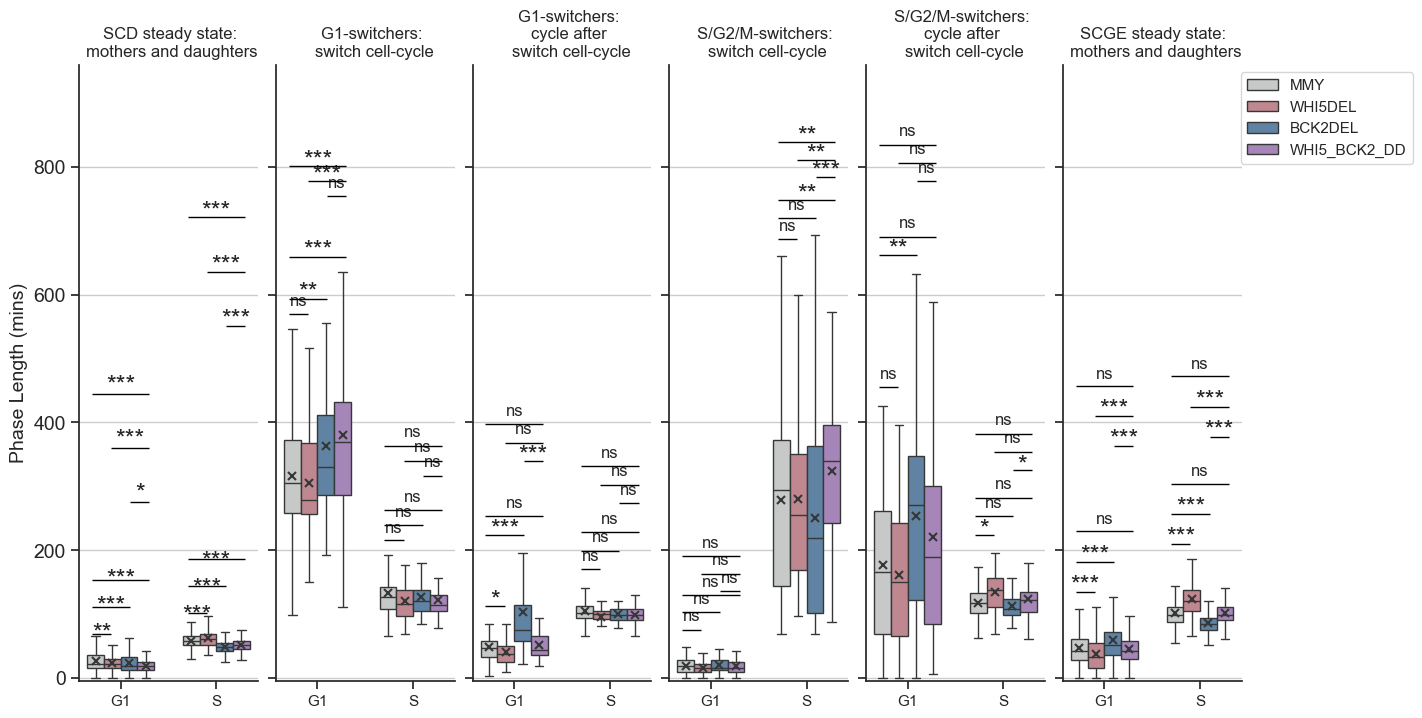

In [31]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4, ax5, ax6)) = plt.subplots(nrows=1, ncols=6, sharex= False, sharey= True, figsize=(15, 8) )
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="time_in_stage_mins", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

x_order = ['G1', 'S']
core.annotate_significance_hue_vs_ref(
      ax=ax1,
      df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      x_col="cell_cycle_stage",
      y_col="time_in_stage_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="MMY",
      min_n=3,
      show_n=False,
      y_gap=0.03,
      bracket_step=0.4,
      test_buffer=0.02,
      text_gap=0.004,
      star_gap=-0.1,
      test="mwu"
)

core.annotate_significance_hue_vs_ref(
      ax=ax1,
      df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      x_col="cell_cycle_stage",
      y_col="time_in_stage_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="WHI5_BCK2_DD",
      min_n=3,
      show_n=False,
      y_gap=1,
      bracket_step=0.4,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)

ax1.set_title("SCD steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Phase Length (mins)", fontsize = 14)

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="time_in_stage_mins",
                hue = "strain",
                ax = ax6,
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax6.set_title("SCGE steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax6.set_ylabel("")

core.annotate_significance_hue_vs_ref(
      ax=ax6,
      df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      x_col="cell_cycle_stage",
      y_col="time_in_stage_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="MMY",
      min_n=3,
      show_n=False,
      y_gap=0.03,
      bracket_step=0.06,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)

core.annotate_significance_hue_vs_ref(
      ax=ax6,
      df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      x_col="cell_cycle_stage",
      y_col="time_in_stage_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="WHI5_BCK2_DD",
      min_n=3,
      show_n=False,
      y_gap=0.3,
      bracket_step=0.06,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

core.annotate_significance_hue_vs_ref(
      ax=ax2,
      df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True],
      x_col="cell_cycle_stage",
      y_col="phase_length_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="MMY",
      min_n=3,
      show_n=False,
      y_gap=0.03,
      bracket_step=0.03,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)

core.annotate_significance_hue_vs_ref(
      ax=ax2,
      df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True],
      x_col="cell_cycle_stage",
      y_col="phase_length_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="WHI5_BCK2_DD",
      min_n=3,
      show_n=False,
      y_gap=0.15,
      bracket_step=0.03,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("G1-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax2.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax4,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
core.annotate_significance_hue_vs_ref(
      ax=ax4,
      df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False],
      x_col="cell_cycle_stage",
      y_col="phase_length_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="MMY",
      min_n=3,
      show_n=False,
      y_gap=0.03,
      bracket_step=0.03,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)

core.annotate_significance_hue_vs_ref(
      ax=ax4,
      df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False],
      x_col="cell_cycle_stage",
      y_col="phase_length_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="WHI5_BCK2_DD",
      min_n=3,
      show_n=False,
      y_gap=0.1,
      bracket_step=0.03,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax4, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax4.set_title("S/G2/M-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax4.set_ylabel("") 

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
core.annotate_significance_hue_vs_ref(
      ax=ax3,
      df=unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True],
      x_col="cell_cycle_stage",
      y_col="phase_length_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="MMY",
      min_n=3,
      show_n=False,
      y_gap=0.03,
      bracket_step=0.03,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)

core.annotate_significance_hue_vs_ref(
      ax=ax3,
      df=unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True],
      x_col="cell_cycle_stage",
      y_col="phase_length_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="WHI5_BCK2_DD",
      min_n=3,
      show_n=False,
      y_gap=0.15,
      bracket_step=0.03,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]), 
#                         x= "cell_cycle_stage", y="phase_length_mins", ax = ax3, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax3.set_title("G1-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax3.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax5,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
core.annotate_significance_hue_vs_ref(
      ax=ax5,
      df=unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False],
      x_col="cell_cycle_stage",
      y_col="phase_length_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="MMY",
      min_n=3,
      show_n=False,
      y_gap=0.03,
      bracket_step=0.03,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)

core.annotate_significance_hue_vs_ref(
      ax=ax5,
      df=unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False],
      x_col="cell_cycle_stage",
      y_col="phase_length_mins",
      hue_col="strain",
      x_order=x_order,
      hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      ref_hue="WHI5_BCK2_DD",
      min_n=3,
      show_n=False,
      y_gap=0.15,
      bracket_step=0.03,
      test_buffer=0.02,
      text_gap=0.01,
      star_gap=-0.01,
      test="mwu"
)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]), 
#                         x= "cell_cycle_stage", y="phase_length_mins", ax = ax5, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax5.set_title("S/G2/M-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax5.set_ylabel("")

#display(unique_phase_first_frame_df[(unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False) 
                                   # & (unique_phase_first_frame_df['strain'] == "WHI5DEL")
                                   # & (unique_phase_first_frame_df['phase_length_mins'] <400)].drop(columns = ['directory']))

ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend([],[], frameon=False)
ax5.legend([],[], frameon=False)
ax6.legend(loc='upper right', bbox_to_anchor=(2, 1))

xtix = ['G1', 'S/G2/M']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)
# ax5.set_xticklabels(xtix, fontsize = 14)
# ax6.set_xticklabels(xtix, fontsize = 14)

ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)



plt.savefig(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\Panel2_switchers_G1_analysis.svg")
plt.show()

# ***Fig 4C: Switchers only - vol at G1 end - selected strains*** 

In [32]:
############################### steady state use old dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              #& (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                             ]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of both cell-cycle stages for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]


############################### nutrient switch switch cycle plotting df prep ############################################################################
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

complete_switch_cycles = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            #& (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase = []
for fposid in ((complete_switch_cycles['f_pos_cell_id']).unique()):
    fposid_df = complete_switch_cycles[complete_switch_cycles['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase.append(phase_df.iloc[:1])
unique_phase_first_frame_df = pd.concat(unique_f_pos_cell_id_phase).reset_index(drop = True)

unique_phase_first_frame_df['phase_length_mins'] = unique_phase_first_frame_df['phase_length']*3
display(unique_phase_first_frame_df['f_pos_cell_id'].loc[unique_phase_first_frame_df['phase_length_mins'] > 1250])

############################### nutrient switch cycle after switch cycle plotting df prep ############################################################################


complete_cycle_after_switch_cycle = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cell_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1) |
                                                               (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0")) 
                                                            #& (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase_2 = []
for fposid in ((complete_cycle_after_switch_cycle['f_pos_cell_id']).unique()):
    fposid_df = complete_cycle_after_switch_cycle[complete_cycle_after_switch_cycle['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase_2.append(phase_df.iloc[:1])
unique_phase_first_frame_df_2 = pd.concat(unique_f_pos_cell_id_phase_2).reset_index(drop = True)

unique_phase_first_frame_df_2['phase_length_mins'] = unique_phase_first_frame_df_2['phase_length']*3




Series([], Name: f_pos_cell_id, dtype: object)

C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1757621977.py:162: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1757621977.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1757621977.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1757621977.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipyker

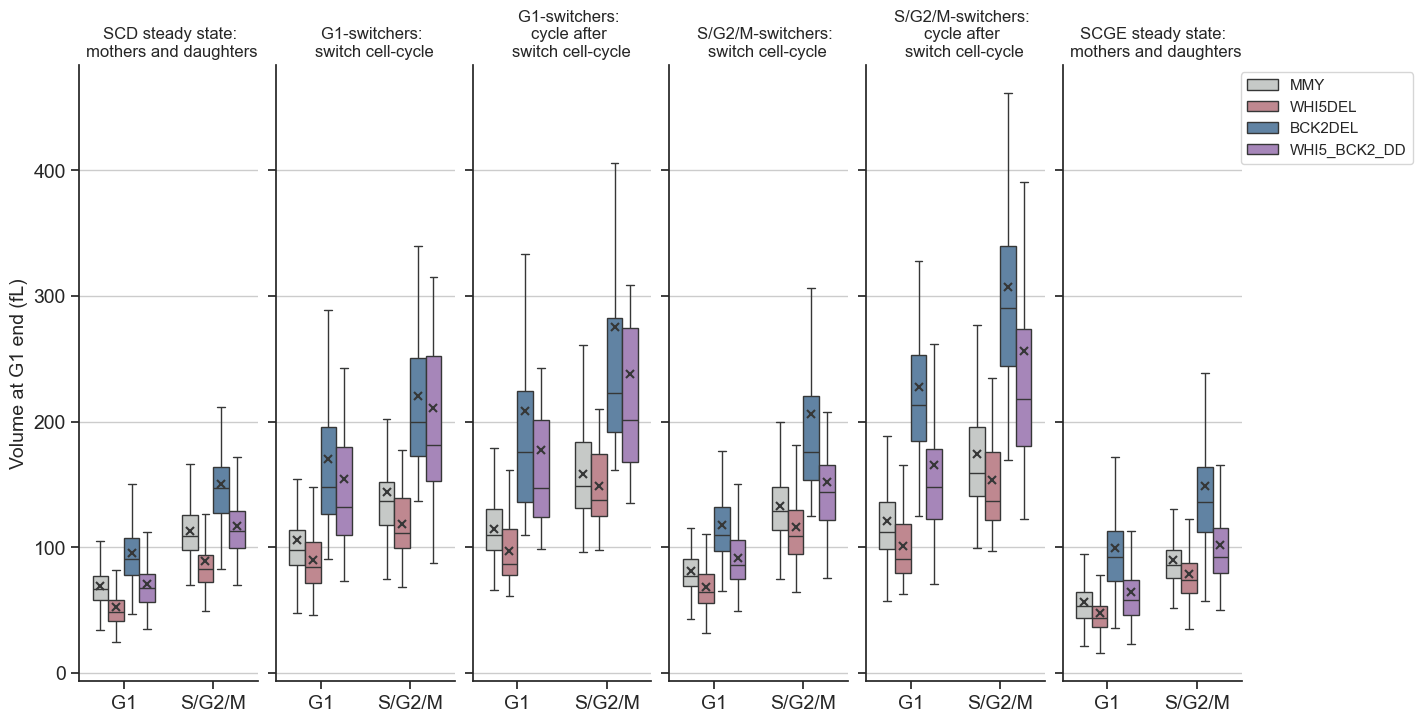

In [33]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4, ax5, ax6)) = plt.subplots(nrows=1, ncols=6, sharex= False, sharey= True, figsize=(15, 8) )

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                order = ['G1', 'S'],
                y="sys_vol_at_frame_inc_G1_cells", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Volume at G1 end (fL)", fontsize = 14)

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                # order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="sys_vol_at_frame_inc_G1_cells",
                hue = "strain",
                ax = ax6,
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax6.set_title("SCGE steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax6.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax2, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("G1-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax2.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax4,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax4, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax4.set_title("S/G2/M-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax4.set_ylabel("") 

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax3, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax3.set_title("G1-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax3.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax5,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax5, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax5.set_title("S/G2/M-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax5.set_ylabel("")

#display(unique_phase_first_frame_df[(unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False) 
                                   # & (unique_phase_first_frame_df['strain'] == "WHI5DEL")
                                   # & (unique_phase_first_frame_df['phase_length_mins'] <400)].drop(columns = ['directory']))

ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend([],[], frameon=False)
ax5.legend([],[], frameon=False)
ax6.legend(loc='upper right', bbox_to_anchor=(2, 1))

xtix = ['G1', 'S/G2/M']
ax1.set_xticklabels(xtix, fontsize = 14)
ax2.set_xticklabels(xtix, fontsize = 14)
ax3.set_xticklabels(xtix, fontsize = 14)
ax4.set_xticklabels(xtix, fontsize = 14)
ax5.set_xticklabels(xtix, fontsize = 14)
ax6.set_xticklabels(xtix, fontsize = 14)
#ax1.set_ylim(0,450)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig3\Panel3_switchers_volatG1andSend.svg")
plt.show()

# ***Fig 4C: Statistics - switch-cell-cycle*** 

In [34]:
from scipy import stats as scipystats
print("G1-switchers switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("G1-switchers switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))



G1-switchers switch cell-cycle G1 stats:
WT n 144
Bck2del n 67
whi5del n 59
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=np.float64(3.307791622909012), pvalue=np.float64(0.0011353438243126898), df=np.float64(180.1067821741331))
WT VS BCK2 TtestResult(statistic=np.float64(-7.047490719396623), pvalue=np.float64(3.2007139380360367e-10), df=np.float64(92.484951808598))
WT VS DD TtestResult(statistic=np.float64(-4.66989453887733), pvalue=np.float64(1.5945922309897052e-05), df=np.float64(63.92187740436918))
DD VS BCK2 TtestResult(statistic=np.float64(-1.274801335674503), pvalue=np.float64(0.20516635974934275), df=np.float64(106.01955115905871))
DD VS WHI5 TtestResult(statistic=np.float64(6.336789008070276), pvalue=np.float64(3.269241843063599e-08), df=np.float64(60.373522445901784))
G1-switchers switch cell-cycle S/G2/M stats:
WT n 132
Bck2del n 56
whi5del n 46
whi5bck2dd n 42
WT VS WHI5 TtestResult(statistic=np.float64(4.1888607598268965), pvalue=np.float64(5.265892500279857e-05), df=np

# ***Fig 4C: Statistics - cycle after switch-cell-cycle*** 

In [35]:
print("G1-switchers cycle after switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("G1-switchers cycle after switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers cycle after switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers cycle after switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))


G1-switchers cycle after switch cell-cycle G1 stats:
WT n 120
Bck2del n 49
whi5del n 34
whi5bck2dd n 34
WT VS WHI5 TtestResult(statistic=np.float64(3.275150103752382), pvalue=np.float64(0.001793407303016432), df=np.float64(57.393838109463246))
WT VS BCK2 TtestResult(statistic=np.float64(-5.164471710184172), pvalue=np.float64(4.160453616670933e-06), df=np.float64(50.23034653765064))
WT VS DD TtestResult(statistic=np.float64(-4.097037337275781), pvalue=np.float64(0.0002341188409656501), df=np.float64(35.161354848970305))
DD VS BCK2 TtestResult(statistic=np.float64(-1.3059861902624006), pvalue=np.float64(0.19525518303579714), df=np.float64(80.97433405802278))
DD VS WHI5 TtestResult(statistic=np.float64(5.095840854415213), pvalue=np.float64(9.122606776042683e-06), df=np.float64(39.233640107029785))
G1-switchers cycle after switch cell-cycle S/G2/M stats:
WT n 91
Bck2del n 39
whi5del n 14
whi5bck2dd n 26
WT VS WHI5 TtestResult(statistic=np.float64(0.9913212005895106), pvalue=np.float64(0.33

# ***Fig 4C: Statistics - steady-state cells*** 

In [36]:
print("SCD steady state volume at G1 end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCD steady state volume at S/G2/M end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCGE steady state volume at G1 end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCGE steady state volume at S/G2/M end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

SCD steady state volume at G1 end stats:
WT n 456
Bck2del n 488
whi5del n 498
whi5bck2dd n 611
WT VS WHI5 TtestResult(statistic=np.float64(14.850995245601297), pvalue=np.float64(5.0975040700743725e-45), df=np.float64(949.8245552716488))
WT VS BCK2 TtestResult(statistic=np.float64(-16.937024073980464), pvalue=np.float64(1.9780776580468875e-55), df=np.float64(822.8743903298803))
WT VS DD TtestResult(statistic=np.float64(-0.7527061154807382), pvalue=np.float64(0.45179861535227395), df=np.float64(1029.4568983629763))
DD VS BCK2 TtestResult(statistic=np.float64(-16.55142388027462), pvalue=np.float64(2.004427338157694e-53), df=np.float64(834.3093568838642))
DD VS WHI5 TtestResult(statistic=np.float64(15.887891238559439), pvalue=np.float64(2.866097562755581e-51), df=np.float64(1086.488342000647))
SCD steady state volume at S/G2/M end stats:
WT n 565
Bck2del n 576
whi5del n 583
whi5bck2dd n 699
WT VS WHI5 TtestResult(statistic=np.float64(16.81774919717342), pvalue=np.float64(8.990034520001396e

# ***Fig 5B: Daughters of switchers - G1 lengths - selected strains*** 

In [37]:
############################### steady state dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              & (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                              & (SS_SCDnSCGE['Daughterhood_binary'] == 1)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of G1 for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]

palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}

############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)
unique_first_G1_frame_df_Sdaughters['phase_length_mins'] = unique_first_G1_frame_df_Sdaughters['phase_length']*3

############################### nutrient switch G1 daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_G1daughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_G1daughters = []
for fposid in ((post_switch_G1daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_G1daughters_complete_G1_df[post_switch_G1daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_G1daughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_G1daughters = pd.concat(unique_f_pos_cell_id_G1daughters).reset_index(drop = True)
unique_first_G1_frame_df_G1daughters['phase_length_mins'] = unique_first_G1_frame_df_G1daughters['phase_length']*3





c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\974006173.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\974006173.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\974006173.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Fi

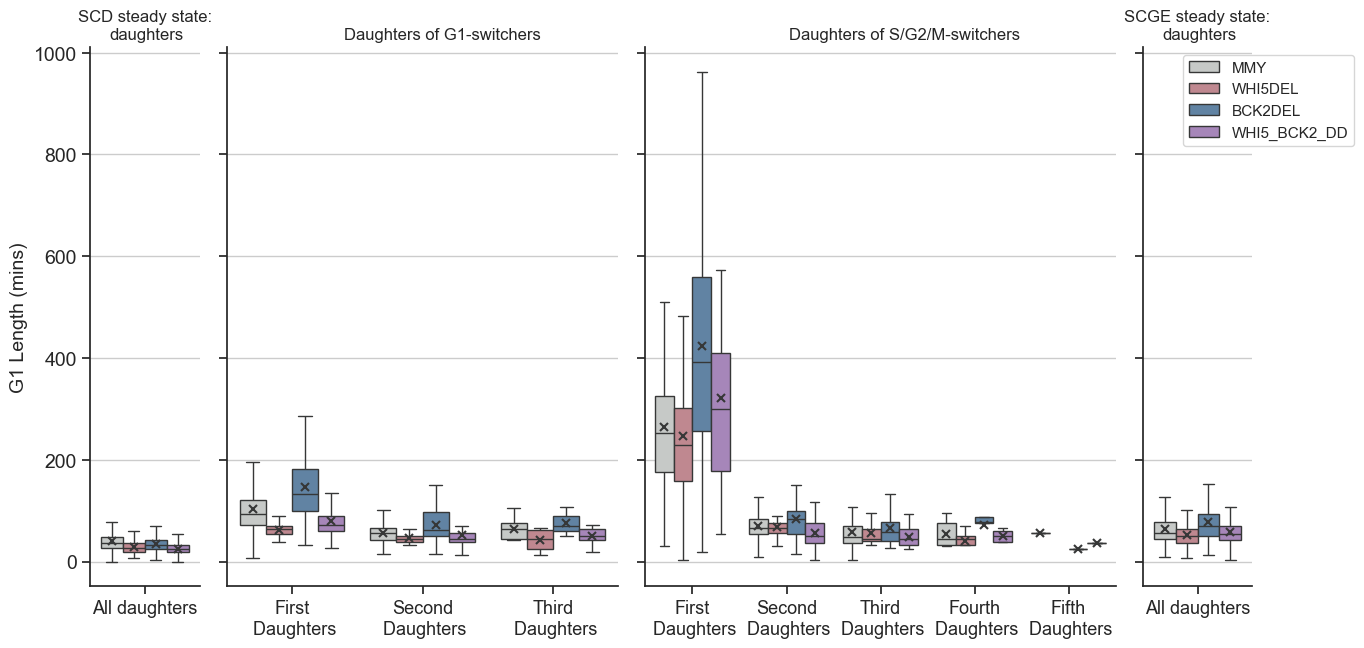

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


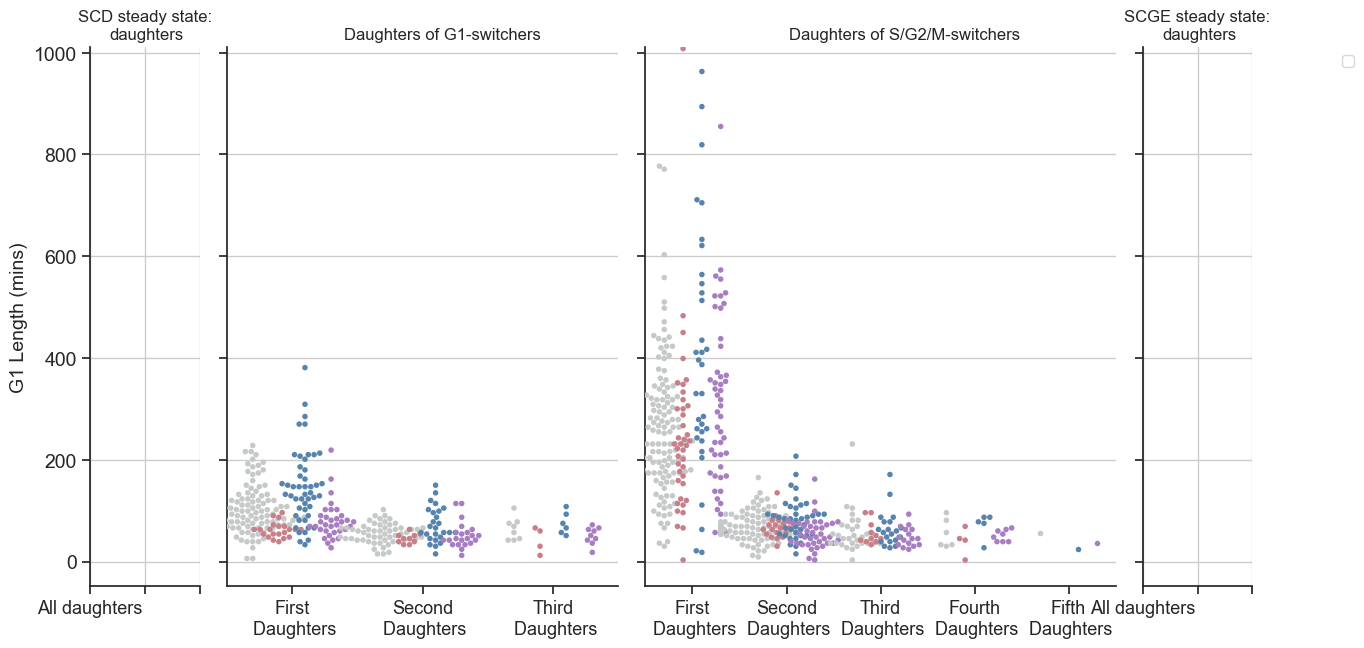

In [38]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
A, ((ax5, ax6, ax7, ax8)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="time_in_stage_mins", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax1.set_ylabel("G1 Length (mins)", fontsize = 14)

ax5.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax5.set_ylabel("G1 Length (mins)", fontsize = 14)



S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                #order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="time_in_stage_mins",
                hue = "strain",
                ax = ax4,
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax4.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax4.set_ylabel("")
ax8.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax8.set_ylabel("")


S = sns.boxplot(data=unique_first_G1_frame_df_G1daughters,
                showmeans = True,
                x= "G1_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_G1daughters, 
                       x= "G1_switch_cells_daughter_wave", y="phase_length_mins", ax = ax6, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax2.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("")
ax6.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax6.set_ylabel("")

S = sns.boxplot(data=unique_first_G1_frame_df_Sdaughters,
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_Sdaughters, 
                       x= "S_switch_cells_daughter_wave", y="phase_length_mins", ax = ax7, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("") 
ax7.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax7.set_ylabel("") 



ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(2, 1))
ax5.legend([],[], frameon=False)
ax6.legend([],[], frameon=False)
ax7.legend([],[], frameon=False)
ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))

# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)


ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax1.set_xticklabels(['All daughters'], fontsize = 13)
ax4.set_xticklabels(['All daughters'], fontsize = 13)

ax5.set_yticklabels(ax5.get_yticklabels(), fontsize = 14)
ax6.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax7.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax5.set_xticklabels(['All daughters'], fontsize = 13)
ax8.set_xticklabels(['All daughters'], fontsize = 13)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
ax7.set_xlabel("")
ax8.set_xlabel("")

S.figure.subplots_adjust(wspace = 0.1)
A.figure.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)
sns.despine(ax = ax7)
sns.despine(ax = ax8)

ax5.set_ylim(ax1.get_ylim())


# S.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel2_daughtersofswitchers_G1_length.svg")
# A.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel2_daughtersofswitchers_G1_length_swarm.svg")
plt.show()

# ***Fig 5B: statistics - selected strains*** 

In [39]:
from scipy import stats as scipystats
print("S-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "MMY") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_length_mins"]), (whi5del_df["phase_length_mins"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_length_mins"]), (bck2del_df["phase_length_mins"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_length_mins"]), (whi5bck2dd_df["phase_length_mins"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_length_mins"]), (bck2del_df["phase_length_mins"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_length_mins"]), (whi5del_df["phase_length_mins"]), equal_var = False))



S-switchers first daughters stats:
WT n 123
Bck2del n 34
whi5del n 40
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=np.float64(0.6126119958151159), pvalue=np.float64(0.5425893873307591), df=np.float64(56.534317931051866))
WT VS BCK2 TtestResult(statistic=np.float64(-3.4539905469509224), pvalue=np.float64(0.001377942375269265), df=np.float64(37.79023744176679))
WT VS DD TtestResult(statistic=np.float64(-1.9079396342152497), pvalue=np.float64(0.060676494315341306), df=np.float64(67.14208691536041))
DD VS BCK2 TtestResult(statistic=np.float64(-1.9180102379621669), pvalue=np.float64(0.060013749005531185), df=np.float64(58.27916529695645))
DD VS WHI5 TtestResult(statistic=np.float64(1.9832269849571966), pvalue=np.float64(0.050462019802750994), df=np.float64(87.94474407517448))


# ***Fig 5C: Daughters of switchers - Vol at G1 end - selected strains*** 

In [40]:
############################### steady state dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              & (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                              & (SS_SCDnSCGE['Daughterhood_binary'] == 1)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of G1 for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]



############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)
unique_first_G1_frame_df_Sdaughters['phase_length_mins'] = unique_first_G1_frame_df_Sdaughters['phase_length']*3

############################### nutrient switch G1 daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_G1daughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_G1daughters = []
for fposid in ((post_switch_G1daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_G1daughters_complete_G1_df[post_switch_G1daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_G1daughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_G1daughters = pd.concat(unique_f_pos_cell_id_G1daughters).reset_index(drop = True)
unique_first_G1_frame_df_G1daughters['phase_length_mins'] = unique_first_G1_frame_df_G1daughters['phase_length']*3





c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 38.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1702812517.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))
C:\Users\timon\AppD

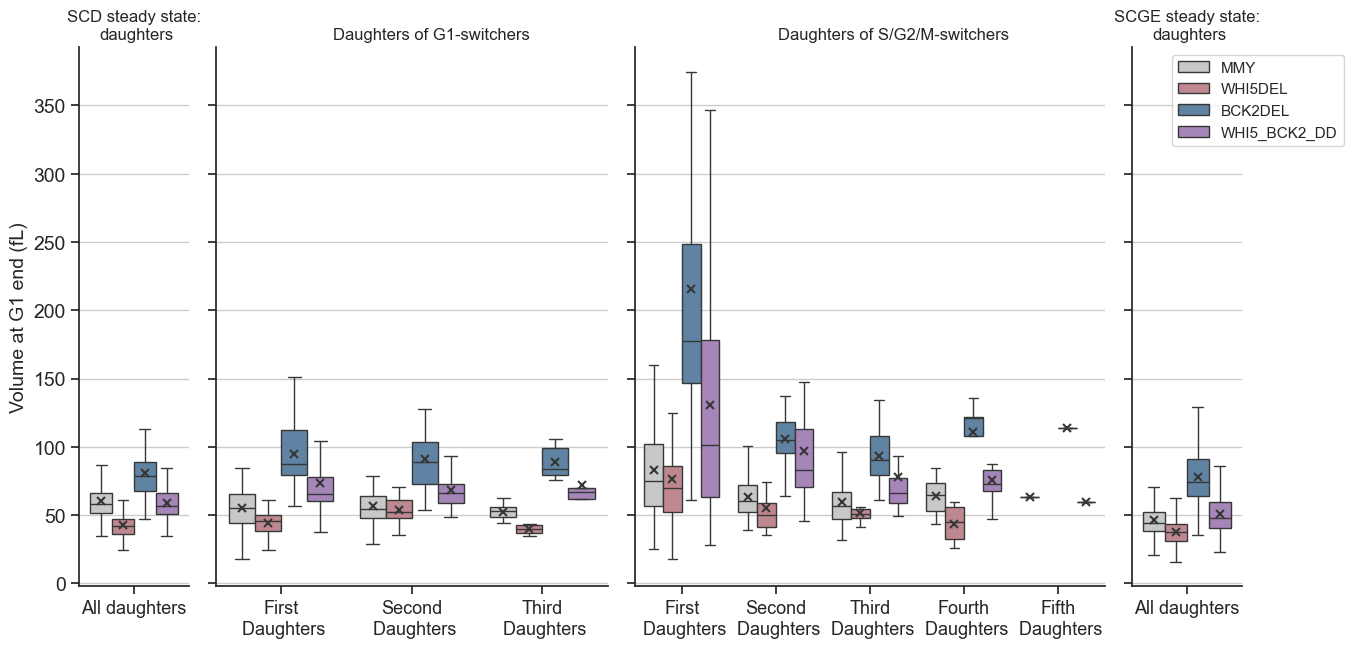

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


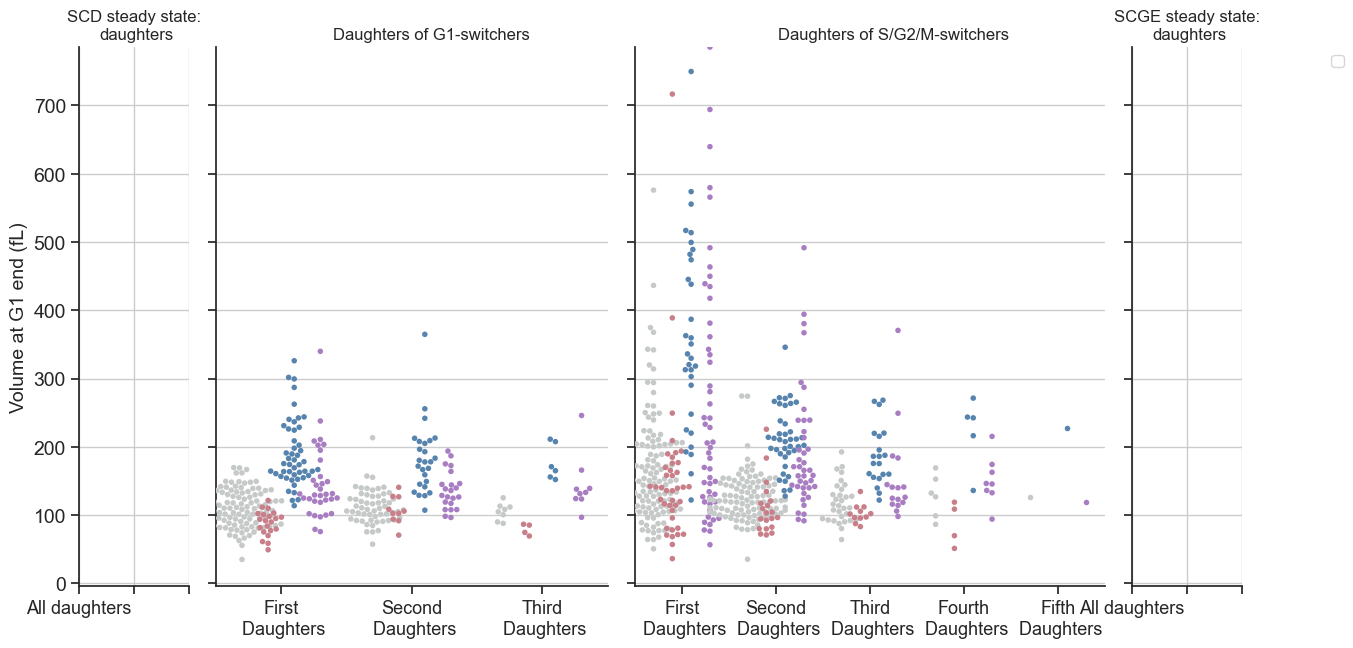

In [41]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
A, ((ax5, ax6, ax7, ax8)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="sys_vol_at_frame_inc_G1_cells", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Volume at G1 end (fL)", fontsize = 14)
ax5.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax5.set_ylabel("Volume at G1 end (fL)", fontsize = 14)



S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                #order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="sys_vol_at_frame_inc_G1_cells",
                hue = "strain",
                ax = ax4,
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax4.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax4.set_ylabel("")
ax8.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax8.set_ylabel("")


S = sns.boxplot(data=unique_first_G1_frame_df_G1daughters,
                showmeans = True,
                x= "G1_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_G1daughters, 
                       x= "G1_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax6, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)


ax2.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("")
ax6.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax6.set_ylabel("")

S = sns.boxplot(data=unique_first_G1_frame_df_Sdaughters,
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_Sdaughters, 
                       x= "S_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax7, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("") 
ax7.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax7.set_ylabel("") 


ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(2, 1))
ax5.legend([],[], frameon=False)
ax6.legend([],[], frameon=False)
ax7.legend([],[], frameon=False)
ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))
# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)


ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax1.set_xticklabels(['All daughters'], fontsize = 13)
ax4.set_xticklabels(['All daughters'], fontsize = 13)

ax5.set_yticklabels(ax5.get_yticklabels(), fontsize = 14)
ax6.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax7.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax5.set_xticklabels(['All daughters'], fontsize = 13)
ax8.set_xticklabels(['All daughters'], fontsize = 13)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
ax7.set_xlabel("")
ax8.set_xlabel("")

S.figure.subplots_adjust(wspace = 0.1)
A.figure.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)
sns.despine(ax = ax7)
sns.despine(ax = ax8)
ax5.set_ylim(ax1.get_ylim())

# A.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel3_daughtersofswitchers_volatG1end_swarm.svg")
#S.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel3_daughtersofswitchers_volatG1end.svg")
plt.show()

# ***Fig 5C: statistics - selected strains*** 

In [42]:
from scipy import stats as scipystats
print("S-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "MMY") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (whi5del_df["phase_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (bck2del_df["phase_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (whi5bck2dd_df["phase_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_volume_at_end"]), (bck2del_df["phase_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_volume_at_end"]), (whi5del_df["phase_volume_at_end"]), equal_var = False))

print("G1-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "MMY") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

print("SCD steady state daughters")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

print("SCGE steady state daughters")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))




S-switchers first daughters stats:
WT n 123
Bck2del n 34
whi5del n 40
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=np.float64(0.6910576377209107), pvalue=np.float64(0.4925304410012181), df=np.float64(53.260660352716926))
WT VS BCK2 TtestResult(statistic=np.float64(-5.446889515442022), pvalue=np.float64(4.3126657536661e-06), df=np.float64(34.5212684009966))
WT VS DD TtestResult(statistic=np.float64(-3.6133283994569703), pvalue=np.float64(0.0006377268721360177), df=np.float64(57.34641029782628))
DD VS BCK2 TtestResult(statistic=np.float64(-3.1348568671599586), pvalue=np.float64(0.0028507471632425447), df=np.float64(51.00633854302823))
DD VS WHI5 TtestResult(statistic=np.float64(3.5192609230044645), pvalue=np.float64(0.0007046094408099218), df=np.float64(83.17048444909689))
G1-switchers first daughters stats:
WT n 103
Bck2del n 48
whi5del n 21
whi5bck2dd n 33
SCD steady state daughters
WT n 198
Bck2del n 214
whi5del n 232
whi5bck2dd n 282
SCGE steady state daughters
WT n 330
Bck2del n

# ***Fig S4: Size control in daughters of S/G2/M switchers - selected strains*** 

In [43]:
#  calculating the diTalia metric: alpha*G1length 

In [44]:

######################################### filter for steady state cells with complete cycles only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_cycle'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5DEL")|
                                            (SS_SCDnSCGE['strain'] == "BCK2DEL")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]

# calculating alpha 
import warnings

with warnings.catch_warnings(record=True):
    for fposid in ((steady_state_completecycles_df['f_pos_cell_id']).unique()):
        selected_cell_df = steady_state_completecycles_df[steady_state_completecycles_df['f_pos_cell_id'] == fposid]
        selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'] = np.log(selected_cell_df['sys_vol_at_frame_inc_G1_cells'])
        slope, intercept, r_value, p_value, std_err = stats.linregress(selected_cell_df['frame_i'],selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'])
        SS_SCDnSCGE.loc[(SS_SCDnSCGE['f_pos_cell_id'] == fposid), 'alpha'] = slope



In [45]:

## filter for nutrient switch first and second daughter wave cells with complete cycles only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
post_switch_daughters_df = selectedstrains_NS_plotting_df[((np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False)|
                                                        (np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False))
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_cycle'] == 1)
                                                      ]

# calculating alpha 
import warnings

with warnings.catch_warnings(record=True):
    for fposid in ((post_switch_daughters_df['f_pos_cell_id']).unique()):
        selected_cell_df = post_switch_daughters_df[post_switch_daughters_df['f_pos_cell_id'] == fposid]
        selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'] = np.log(selected_cell_df['combined_mother_bud_volume'])
        slope, intercept, r_value, p_value, std_err = stats.linregress(selected_cell_df['frame_i'],selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'])
        selectedstrains_NS_plotting_df.loc[(selectedstrains_NS_plotting_df['f_pos_cell_id'] == fposid), 'alpha'] = slope
        
        

In [46]:

# calculate growth-rate standardised G1 length for each cell that has an alpha: (alpha*G1 length (mins)) - steady state

with warnings.catch_warnings(record=True):
    SS_SCDnSCGE['alpha_G1_length_frames'] = SS_SCDnSCGE['alpha']*SS_SCDnSCGE['len_G1']
    SS_SCDnSCGE['ln_birth_or_div_vol'] = np.log(SS_SCDnSCGE['Birth_or_div_vol_fl'])
    
# calculate growth-rate standardised G1 length for each cell that has an alpha: (alpha*G1 length (mins)) - nutrient switch

with warnings.catch_warnings(record=True):
    #selectedstrains_NS_plotting_df['phase_length_mins'] =  selectedstrains_NS_plotting_df['phase_length']*3
    selectedstrains_NS_plotting_df['alpha_phase_length_frames'] = (selectedstrains_NS_plotting_df['alpha'])*(selectedstrains_NS_plotting_df['phase_length'])
    selectedstrains_NS_plotting_df['ln_birth_or_div_vol'] = np.log(selectedstrains_NS_plotting_df['birth_or_div_vol'])
    
#palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}
   

In [47]:


###############################################  steadystate  #####################################################################

steadystate_completecycles_df = SS_SCDnSCGE[ (SS_SCDnSCGE['complete_phase'] == True) 
                                            & (SS_SCDnSCGE['Daughterhood_binary'] == 1)
                                           & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5DEL")|
                                            (SS_SCDnSCGE['strain'] == "BCK2DEL")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))]
SCD_steadystate_df = steadystate_completecycles_df[steadystate_completecycles_df['growthmedium'] == "SCD"]
SCGE_steadystate_df = steadystate_completecycles_df[steadystate_completecycles_df['growthmedium'] == "SCGE"]

#unique plotting df SCD
unique_f_pos_cell_id = []
for fposid in ((SCD_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCD_steadystate_df[SCD_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
SCD_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True) 
SCD_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCD_SS"

#unique plotting df SCGE
unique_f_pos_cell_id_5 = []
for fposid in ((SCGE_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCGE_steadystate_df[SCGE_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_5.append(fposid_df.iloc[:1])
SCGE_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id_5).reset_index(drop = True)
SCGE_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCGE_SS"
            
##################################################  nutrient switch  ###################################################################

nutrientswitch_complete_wave_cycles_df =  selectedstrains_NS_plotting_df[((np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False))
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                      ]


# unique plotting df nutrient switch 
unique_f_pos_cell_id_3 = []
for fposid in ((nutrientswitch_complete_wave_cycles_df['f_pos_cell_id']).unique()):
    fposid_df = nutrientswitch_complete_wave_cycles_df[nutrientswitch_complete_wave_cycles_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_3.append(fposid_df.iloc[:1])
nutrientswitch_daughterwaves_plotting_df = pd.concat(unique_f_pos_cell_id_3).reset_index(drop = True)
nutrientswitch_daughterwaves_plotting_df['alpha_G1_length_frames'] = nutrientswitch_daughterwaves_plotting_df['alpha_phase_length_frames']

for daughter_wave in nutrientswitch_daughterwaves_plotting_df['S_switch_cells_daughter_wave'].unique():
    nutrientswitch_daughterwaves_plotting_df.loc[(nutrientswitch_daughterwaves_plotting_df['S_switch_cells_daughter_wave'] == daughter_wave), 'plotting_col_ref'] = f'daughter_wave_{daughter_wave}'

figure_plotting_df = pd.concat([SCD_steadystate_daughters_plotting_df, SCGE_steadystate_daughters_plotting_df, nutrientswitch_daughterwaves_plotting_df]).reset_index(drop = True)


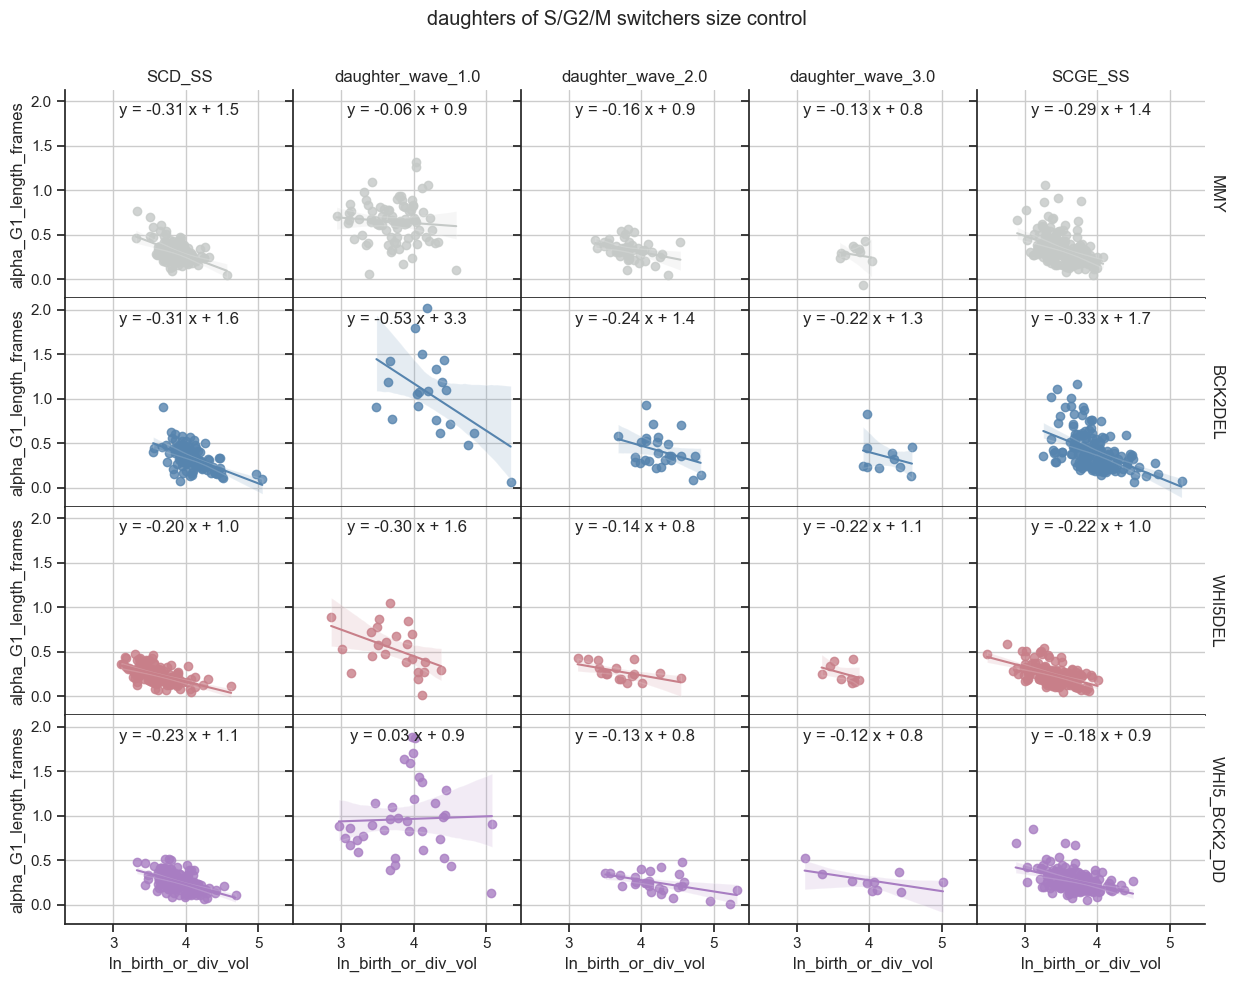

In [48]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

def annotate(data, **kws):
        ax = plt.gca()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
        ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
                horizontalalignment='center',
                verticalalignment='center',
                transform=ax.transAxes)
        #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df[(figure_plotting_df['plotting_col_ref'] != "daughter_wave_4.0") &
                                      (figure_plotting_df['plotting_col_ref'] != "daughter_wave_5.0")], 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'daughter_wave_1.0', 'daughter_wave_2.0', 'daughter_wave_3.0', 'SCGE_SS'],
                  row = "strain", 
                  hue = "strain", 
                  palette = palette,
                  height = 2.5,
                  aspect  =1,
                  margin_titles = True)


b.map_dataframe(sns.regplot, 
      "ln_birth_or_div_vol",
      "alpha_G1_length_frames")


b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
b.fig.suptitle("daughters of S/G2/M switchers size control")
b.figure.subplots_adjust(wspace=0, hspace=0)
b.set()
# ax1.set_title("SCD steady state daughters")
# ax1.set_xlabel("ln(Birth volume)")
# ax1.set_ylabel("G1 Length*Growth Rate")
# ax1.set_ylim(-0.5,4)
# ax1.set_xlim(2,6)
#ax2.set_xscale("log")

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\supplement\Fig5\panel1.svg", dpi =150)

plt.show()

# ***Fig 7B and 7C: Daughters of S/G2/M switchers - G1 length and vol at G1 end*** 

In [49]:

############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)


############################### pre-switch steady state dataprep ############################################################################

pre_switch_daughters_complete_G1_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['growthmedium'] == "SCD") 
                                                                    & (selectedstrains_NS_plotting_df['generation_num'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['phase_saw_switch'] == False)
                                                                    ]
# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_daughters_complete_G1_df[pre_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)
unique_first_G1_frame_df_pre['S_switch_cells_daughter_wave'] = 0

preswitch_plus_postswitch = pd.concat([unique_first_G1_frame_df_Sdaughters, unique_first_G1_frame_df_pre])
preswitch_plus_postswitch['phase_length_mins'] = (preswitch_plus_postswitch['phase_length'])*3




C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1173944422.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend(loc='upper right', bbox_to_anchor=(1, 1))
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1173944422.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1173944422.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1173944422.py:103: UserWarning: set_ticklabels() should only be used with a fixed nu

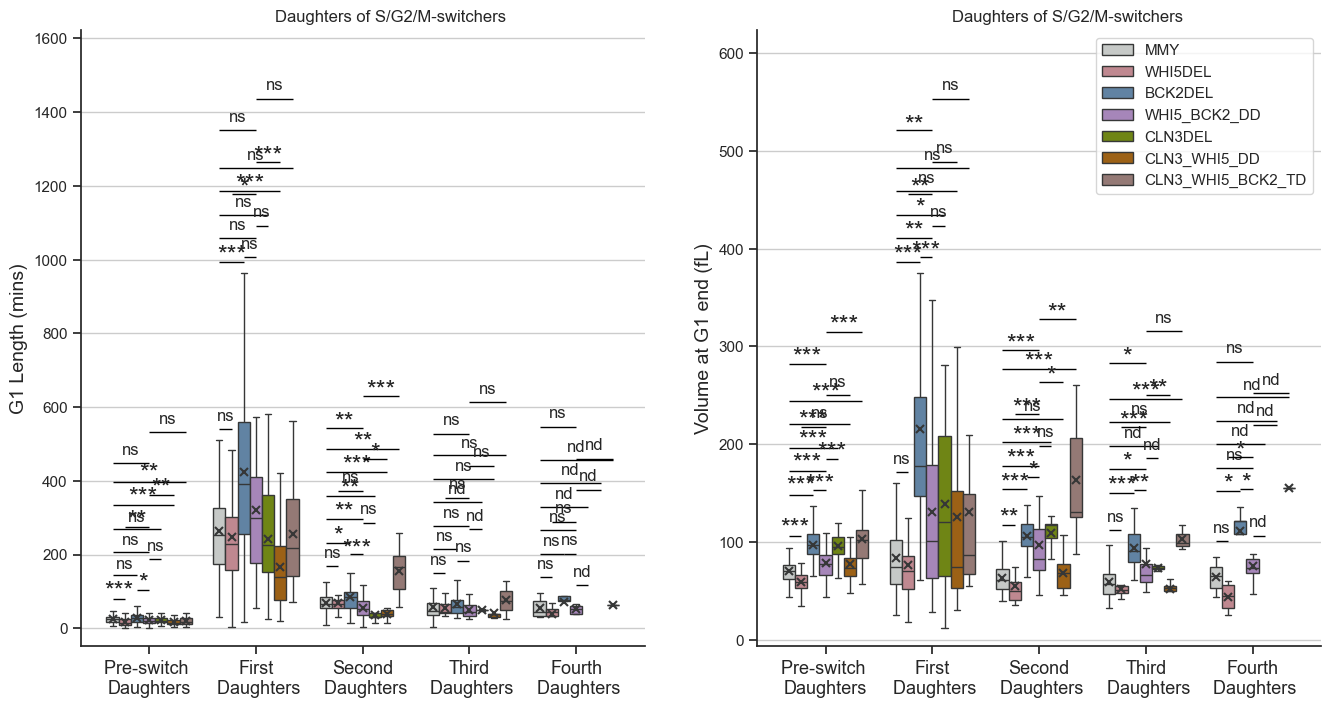

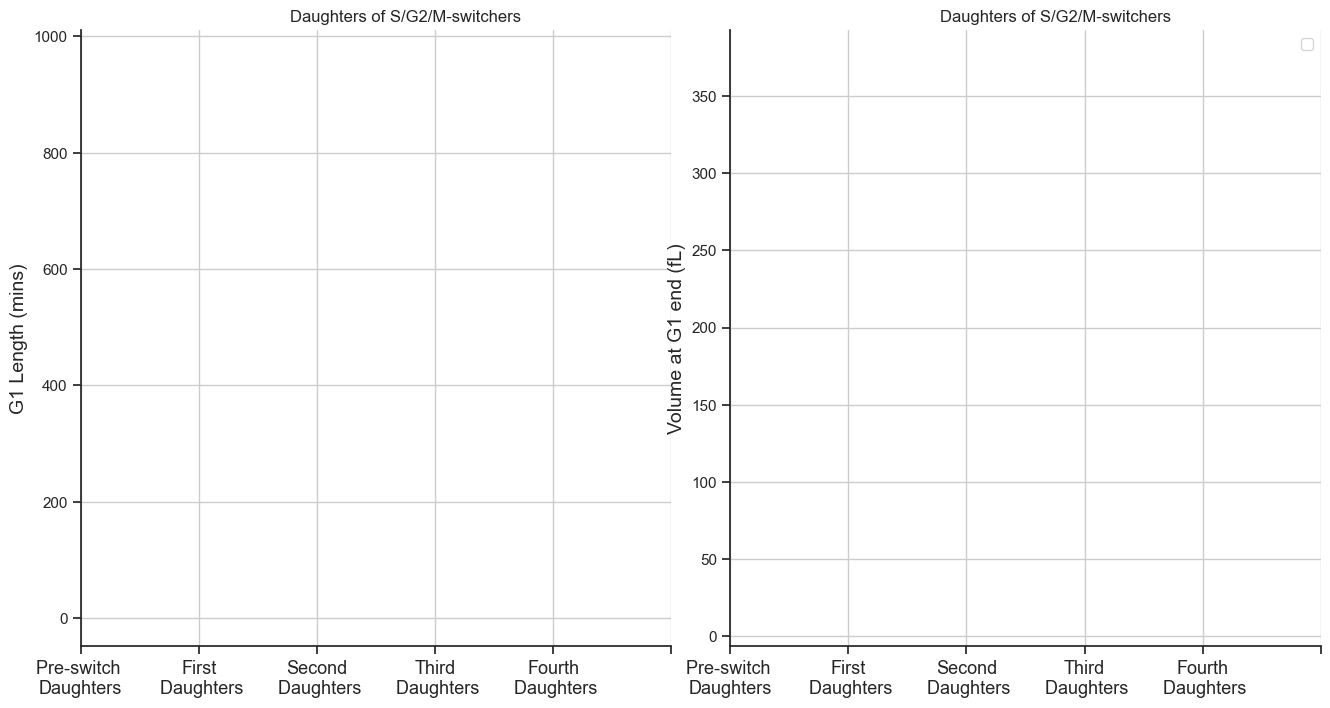

In [50]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", 
          "WHI5_BCK2_DD":"#a87dc2", "CLN3DEL": "#7a9703", "CLN3_WHI5_DD": "#b26400", "CLN3_WHI5_BCK2_TD": "#997570"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(16, 8))
A, (ax3, ax4) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(16, 8))



S = sns.boxplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax1,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# A = sns.swarmplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5], 
#                        x= "S_switch_cells_daughter_wave", y="phase_length_mins", ax = ax3, hue = "strain", 
#                         hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
#                         palette = palette, dodge = True, size = 4)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax1.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax1.set_ylabel("")
ax1.set_ylabel("G1 Length (mins)", fontsize = 14)

ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("")
ax3.set_ylabel("G1 Length (mins)", fontsize = 14)

S = sns.boxplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

# A = sns.swarmplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5], 
#                        x= "S_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax4, hue = "strain", 
#                         hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
#                         palette = palette, dodge = True, size = 4)
# sns.swarmplot(x = "S_switch_cells_daughter_wave", y="phase_length_mins",
#                 ax = ax1, hue = "strain", data =preswitch_plus_postswitch, 
#               dodge = True, legend = False, edgecolor = "black", linewidth = 0.5, size = 3, color = 'black')
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax3, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("Volume at G1 end (fL)", fontsize = 14) 
ax4.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax4.set_ylabel("Volume at G1 end (fL)", fontsize = 14) 


ax1.legend([],[], frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax4.set_ylim(ax2.get_ylim())
ax3.set_ylim(ax1.get_ylim())
ax1.set_xlabel("") 
ax2.set_xlabel("") 
ax3.set_xlabel("") 
ax4.set_xlabel("") 
# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)
# ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
# ax2.set_yticklabels(ax2.get_yticklabels(), fontsize = 14)
# ax3.set_yticklabels(ax3.get_yticklabels(), fontsize = 14)
# ax4.set_yticklabels(ax4.get_yticklabels(), fontsize = 14)

ax1.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax2.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax4.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)

plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
import importlib
import core
importlib.reload(core)

annot_df = preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5].copy()
x_order_wave = sorted(annot_df['S_switch_cells_daughter_wave'].dropna().unique())
all_strains = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"]
for _ax, _ycol in [(ax1, "phase_length_mins"), (ax2, "phase_volume_at_end")]:
    core.annotate_significance_hue_vs_ref(
        ax=_ax,
        df=annot_df,
        x_col="S_switch_cells_daughter_wave",
        y_col=_ycol,
        hue_col="strain",
        x_order=x_order_wave,
        hue_order=all_strains,
        ref_hue="MMY",
        min_n=3,
        show_n=False,
        y_gap=0.03,
        bracket_step=0.06,
        test_buffer=0.02,
        text_gap=0.01,
        star_gap=-0.01,
        test="mwu"
    )
    core.annotate_significance_hue_vs_ref(
        ax=_ax,
        df=annot_df,
        x_col="S_switch_cells_daughter_wave",
        y_col=_ycol,
        hue_col="strain",
        x_order=x_order_wave,
        hue_order=all_strains,
        ref_hue="WHI5_BCK2_DD",
        min_n=3,
        show_n=False,
        y_gap=0.03,
        bracket_step=0.06,
        test_buffer=0.02,
        text_gap=0.01,
        star_gap=-0.01,
        test="mwu"
    )

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel2_daughtersofSswitchers_G1_length_and_volatG1end.svg")
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel2_daughtersofSswitchers_G1_length_and_volatG1end_swarm.svg")
plt.show()


In [51]:
print("S-switchers first daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers second daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers third daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers fourth daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

S-switchers first daughters stats:
cln3del n 16
whi5cln3dd n 39
whi5cln3bck2del n 11
S-switchers second daughters stats:
cln3del n 5
whi5cln3dd n 15
whi5cln3bck2del n 7
S-switchers third daughters stats:
cln3del n 2
whi5cln3dd n 6
whi5cln3bck2del n 3
S-switchers fourth daughters stats:
cln3del n 0
whi5cln3dd n 0
whi5cln3bck2del n 1


# ***Fig 7A: Birth volume pre-switch steady state cells*** 

In [52]:
############################### pre-switch steady state dataprep ############################################################################

pre_switch_complete_G1_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['growthmedium'] == "SCD")
                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['phase_saw_switch'] == False)
                                                                    ]
# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_complete_G1_df[pre_switch_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)



C:\Users\timon\AppData\Local\Temp\ipykernel_31232\3054634126.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Mothers','Daughters'], fontsize = 17)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\3054634126.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 17)


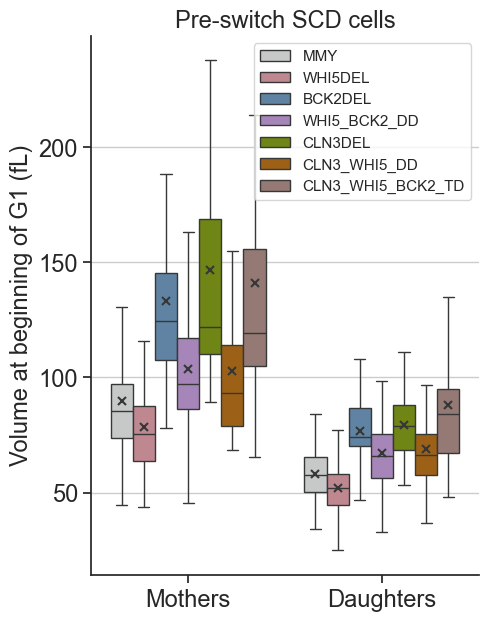

In [53]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", 
          "WHI5_BCK2_DD":"#a87dc2", "CLN3DEL": "#7a9703", "CLN3_WHI5_DD": "#b26400", "CLN3_WHI5_BCK2_TD": "#997570"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}

S, (ax1) = plt.subplots(nrows=1, ncols=1, sharex= False, sharey= True, figsize=(5, 7))


S = sns.boxplot(data=unique_first_G1_frame_df_pre,
                showmeans = True,
                x= "daughterhood_binary",
                y="cell_vol_fl",
                ax = ax1,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax1.set_title("Pre-switch SCD cells", fontsize = 17)
ax1.set_ylabel("")
ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax1.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax1.set_xticklabels(['Mothers','Daughters'], fontsize = 17)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 17)
ax1.set_xlabel("")



# plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)



#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel1_preswitchcells_vol_at_birth.svg")
plt.show()

In [54]:
print("pre-switch daughters stats:")
cln3del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5cln3dd_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5cln3bck2del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_BCK2_TD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
WT_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "MMY") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
bck2del_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))
print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("pre-switch mothers stats:")
cln3del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5cln3dd_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5cln3bck2del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_BCK2_TD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
WT_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "MMY") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
bck2del_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5bck2dd_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))
print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))



pre-switch daughters stats:
WT n 164
Bck2del n 73
whi5del n 82
whi5bck2dd n 77
cln3del n 44
whi5cln3dd n 55
whi5cln3bck2del n 37
pre-switch mothers stats:
WT n 209
Bck2del n 95
whi5del n 87
whi5bck2dd n 95
cln3del n 48
whi5cln3dd n 61
whi5cln3bck2del n 34


# ***Fig S5: Death Analysis*** 

In [55]:
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")]

In [56]:
# add 'does_cell_die_in_experiment', 'does_cell_die_in_this_cycle' and 'does_cell_die_in_this_phase' to nutrient switch data
import warnings

with warnings.catch_warnings(record=True):
    
    list_for_joining = []
    i=0
    for rep in selectedstrains_NS_plotting_df['rep'].unique():
        rep_df = selectedstrains_NS_plotting_df[selectedstrains_NS_plotting_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    
                    if sum(cell_df['is_cell_dead']) > 0:
                        cell_df['does_cell_die_in_experiment'] = 1
                        if strain == "MMY":
                            i=i+1
                    else:
                        cell_df['does_cell_die_in_experiment'] = 0
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        if sum(cycle_df['is_cell_dead']) > 0:
                            cycle_df['does_cell_die_in_this_cycle'] = 1
                        else:
                            cycle_df['does_cell_die_in_this_cycle'] = 0    
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    plotting_df = pd.concat(list_for_joining)   

In [57]:
# add 'does_cell_die_in_experiment', 'does_cell_die_in_this_cycle' and 'does_cell_die_in_this_phase' to steady state data
import warnings

with warnings.catch_warnings(record=True):
    
    list_for_joining = []
    i=0
    for rep in SS_SCDnSCGE['rep'].unique():
        rep_df = SS_SCDnSCGE[SS_SCDnSCGE['rep'] == rep]
        for medium in rep_df['growthmedium'].unique():
            medium_df = rep_df[rep_df['growthmedium'] == medium]
            for strain in medium_df['strain'].unique():
                strain_df = medium_df[medium_df['strain'] == strain]
                for pos in (strain_df['position']).unique():
                    pos_df = strain_df[strain_df["position"] == pos]
                    pos_max_frame = pos_df['frame_i'].max()
                    pos_min_frame = pos_df['frame_i'].min()
                    for cell in (pos_df['Cell_ID']).unique():
                        cell_df = pos_df[pos_df["Cell_ID"] == cell]

                        if sum(cell_df['is_cell_dead']) > 0:
                            cell_df['does_cell_die_in_experiment'] = 1
                            if strain == "MMY":
                                i=i+1
                        else:
                            cell_df['does_cell_die_in_experiment'] = 0
                        for cycle in (cell_df['generation_num']).unique(): 
                            cycle_df = cell_df[cell_df["generation_num"] == cycle]
                            cycle_df = cycle_df.sort_values(by = 'frame_i')
                            if sum(cycle_df['is_cell_dead']) > 0:
                                cycle_df['does_cell_die_in_this_cycle'] = 1
                            else:
                                cycle_df['does_cell_die_in_this_cycle'] = 0    
                            for phase in (cycle_df['cell_cycle_stage'].unique()):
                                phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                                if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                    phase_df['complete_phase'] = 1
                                    phase_df['does_cell_die_in_this_phase'] = 0
                                if sum(phase_df['is_cell_dead']) > 0:
                                    phase_df['complete_phase'] = 0
                                    phase_df['does_cell_die_in_this_phase'] = 1
                                else:
                                    phase_df['does_cell_die_in_this_phase'] = 0
                                list_for_joining.append(phase_df)
    steady_state_plotting_df = pd.concat(list_for_joining)  

In [58]:
# dataprep  steadystate  
# only keep complete cycles and cycles where cells died (drop cycles that are incomplete not due to dying but due to end or beginning of experiment)
steady_state_complete_plus_dead_cycles_df = steady_state_plotting_df.drop(steady_state_plotting_df[(steady_state_plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)

#select strains and split by media
steadystate_df = steady_state_complete_plus_dead_cycles_df[(steady_state_complete_plus_dead_cycles_df['strain'] == "MMY")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "WHI5DEL")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "BCK2DEL")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "WHI5_BCK2_DD")]
SCD_steadystate_df = steadystate_df[steadystate_df['growthmedium'] == "SCD"]
SCGE_steadystate_df = steadystate_df[steadystate_df['growthmedium'] == "SCGE"]

#get only first G1 frame for each cell-cycle SCD
unique_f_pos_cell_id = []
for fposid in ((SCD_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCD_steadystate_df[SCD_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
SCD_steadystate_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True) 


#get only first G1 frame for each cell-cycle SCGE
unique_f_pos_cell_id_5 = []
for fposid in ((SCGE_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCGE_steadystate_df[SCGE_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_5.append(fposid_df.iloc[:1])
SCGE_steadystate_plotting_df = pd.concat(unique_f_pos_cell_id_5).reset_index(drop = True)


C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1197686347.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  steady_state_complete_plus_dead_cycles_df = steady_state_plotting_df.drop(steady_state_plotting_df[(steady_state_plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)


In [59]:
# dataprep  nutrient switch  
# only keep complete cycles and cycles where cells died (drop cycles that are incomplete not due to dying but due to end or beginning of experiment)

complete_plus_dead_cycles_df = plotting_df.drop(plotting_df[(plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)

#get only first G1 frame for each cell cycle
first_frame_list = []
for cycle in complete_plus_dead_cycles_df.f_pos_cell_id.unique():
    cycle_df = complete_plus_dead_cycles_df[complete_plus_dead_cycles_df['f_pos_cell_id'] == cycle]
    first_frame_list.append(cycle_df.iloc[:1])
all_first_frame_df = pd.concat(first_frame_list).reset_index(drop = True)

# from nutrient switch data, drop cycles that were completed pre-switch because they do not reflect death in nutrient-switch conditions
first_frame_df = all_first_frame_df.drop(all_first_frame_df[(all_first_frame_df['growthmedium'] == "SCD") & (all_first_frame_df['cycle_saw_switch'] == False)].index)

C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1571854544.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1571854544.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1571854544.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
C:\Users\timon\AppData\Local\Temp\ipykernel_31232\1571854544.py:80: UserWarning: set_ticklabels() should only be used with a fixed

Text(0.5, 0, '')

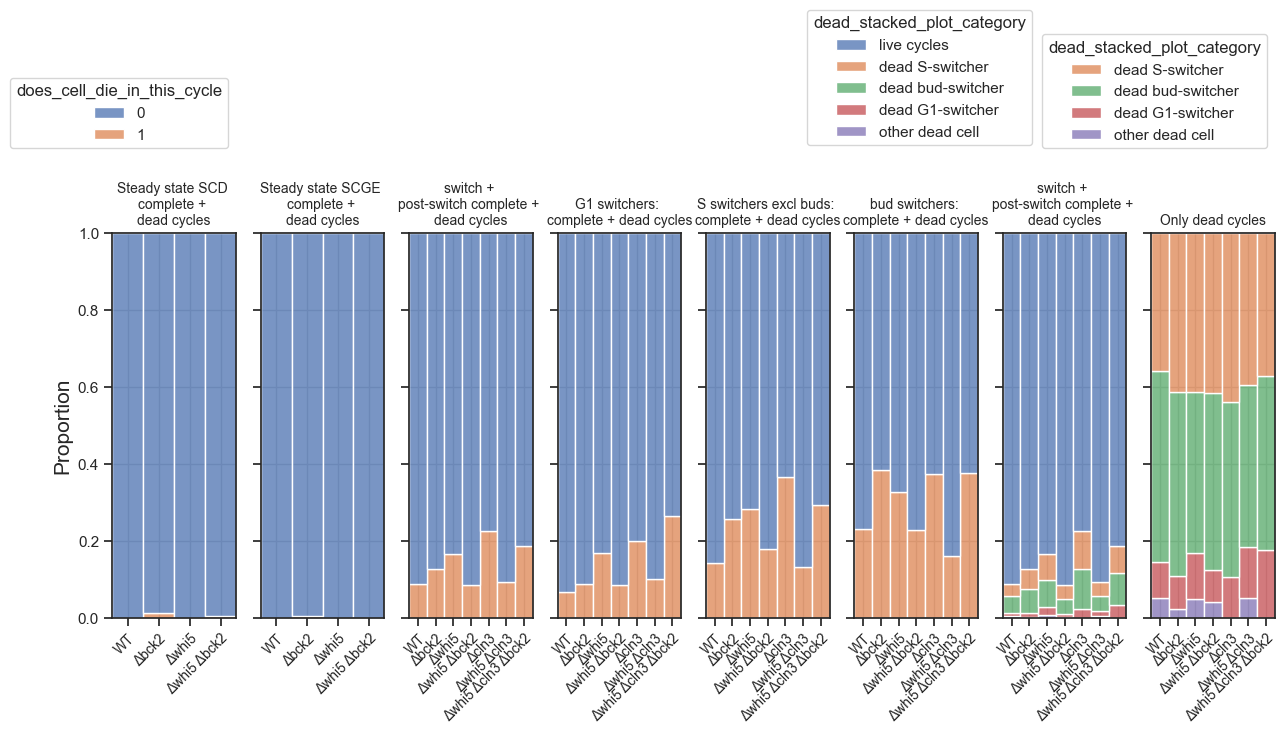

In [60]:
# plot
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

a, (ax1, ax0, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(nrows=1, ncols=8, sharex= False, sharey= True, figsize=(15, 5))

######### complete + dead cycles of steady state SCD cells #######################################################################
a = sns.histplot(data = SCD_steadystate_plotting_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD"],
                 multiple = "fill", 
                 ax=ax1,
                 discrete = True)
sns.move_legend(ax1, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax1.set_title("Steady state SCD \ncomplete + \ndead cycles", fontsize = 10)
ax1.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax1.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax1.set_xlabel("")

######### complete + dead cycles of steady state SCGE cells #######################################################################
a = sns.histplot(data = SCGE_steadystate_plotting_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD"],
                 multiple = "fill", 
                 ax=ax0,
                 discrete = True)
#sns.move_legend(ax0, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax0.set_title("Steady state SCGE \ncomplete + \ndead cycles", fontsize = 10)
ax0.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax0.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
plt.setp(ax0.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax0.set_xlabel("")
######### complete + dead cycles of nutrient switch facing ro post-switch cells #######################################################################
a = sns.histplot(data = first_frame_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax2,
                 discrete = True)
#sns.move_legend(ax2, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax2.set_title("switch + \npost-switch complete + \ndead cycles", fontsize = 10)
ax2.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax2.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax2.set_xlabel("")

######### complete + dead cycles of cells that saw switch in G1 #######################################################################
a = sns.histplot(data = first_frame_df[first_frame_df['cell_saw_switch_in_G1'] == True], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax3,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax3.set_title("G1 switchers: \ncomplete + dead cycles", fontsize = 10)
ax3.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax3.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax3.set_xlabel("")

######### complete + dead cycles of cells that saw switch in S excl buds #######################################################################
a = sns.histplot(data = first_frame_df[(first_frame_df['cell_saw_switch_in_S'] == True) & (first_frame_df['cell_saw_switch_as_bud'] == False)], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax4,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax4.set_title("S switchers excl buds: \ncomplete + dead cycles", fontsize = 10)
ax4.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax4.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax4.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax4.set_xlabel("")

######### complete + dead cycles of cells that saw switch as buds #######################################################################
a = sns.histplot(data = first_frame_df[(first_frame_df['cell_saw_switch_in_S'] == True) & (first_frame_df['cell_saw_switch_as_bud'] == True)], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax5,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax5.set_title("bud switchers: \ncomplete + dead cycles", fontsize = 10)
ax5.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax5.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax5.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax5.set_xlabel("")
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1), 'dead_stacked_plot_category'] = "other dead cell"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_S'] == True) & 
                   (first_frame_df['cell_saw_switch_as_bud'] == True), 'dead_stacked_plot_category'] = "dead bud-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_S'] == True) & 
                   (first_frame_df['cell_saw_switch_as_bud'] == False), 'dead_stacked_plot_category'] = "dead S-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_G1'] == True), 'dead_stacked_plot_category'] = "dead G1-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == False), 'dead_stacked_plot_category'] = "live cycles"

######### complete + dead cycles of ALL CELLS #######################################################################


a = sns.histplot(data = first_frame_df, 
                 hue = "dead_stacked_plot_category", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax6,
                 discrete = True)
sns.move_legend(ax6, "upper right", bbox_to_anchor=(0.3, 1.6))
#display(ax1.get_xticklabels())
ax6.set_title("switch + \npost-switch complete + \ndead cycles", fontsize = 10)
ax6.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax6.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax6.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax6.set_xlabel("")

######### dead cycles of ALL CELLS #######################################################################
palette = ['#dd8452','#55a868', '#c44e52', '#8172b3']
a = sns.histplot(data = first_frame_df[first_frame_df['does_cell_die_in_this_cycle'] == 1], 
                 hue = "dead_stacked_plot_category", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax7,
                 palette=palette,
                 discrete = True)
sns.move_legend(ax7, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax7.set_title("Only dead cycles", fontsize = 10)
ax7.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax7.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax7.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax7.set_xlabel("")
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel3_death_analysis_updated_150724.svg", bbox_inches = 'tight')

In [61]:
# colours and labels were edited further in inkscape

# ***Fig 3A: Calculating total number of complete cycles for paper*** 

In [62]:
#nutrient-switch data (selected strains only)
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")
                                                                    ]
complete_cycles = selectedstrains_NS_plotting_df[selectedstrains_NS_plotting_df['complete_cycle'] == 1]
pos_len= 0
complete_cycle_length =len(complete_cycles.f_pos_cell_id.unique())
for rep in ((complete_cycles['rep']).unique()):
    rep_df = complete_cycles[complete_cycles['rep'] == rep]
    for strain in ((rep_df['strain']).unique()):
        strain_df = rep_df[rep_df['strain'] == strain]
        pos_len =pos_len + len(strain_df.position.unique())

display("number of complete cycles (nutrient switch data only):", complete_cycle_length)
display("number of positions (nutrient switch data only):", pos_len)

#for selected strains in steady-state, add no of positions and complete cell cycles to what was calculated for nutrient switch above
complete_cycles = SS_SCDnSCGE[SS_SCDnSCGE['complete_cycle'] == 1]
for rep in ((complete_cycles['rep']).unique()):
    rep_df = complete_cycles[complete_cycles['rep'] == rep]
    for medium in ((rep_df['growthmedium']).unique()):
        medium_df = rep_df[rep_df['growthmedium'] == medium]
        for strain in ((medium_df['strain']).unique()):
            strain_df = medium_df[medium_df['strain'] == strain]
            if ((strain == "CCR4DEL") | 
                (strain == "WHI5_CCR4_DD")) & (medium == "SCGE"):
                pass
            else:
                pos_len =pos_len + len(strain_df.position.unique())
                complete_cycle_length =complete_cycle_length + len(strain_df.f_pos_cell_id.unique())
display("total positions", pos_len)
display("total complete cycles", complete_cycle_length)


'number of complete cycles (nutrient switch data only):'

6226

'number of positions (nutrient switch data only):'

149

'total positions'

269

'total complete cycles'

9219

In [63]:
# add to this the complete cycles and position numbers from cell cycle marker experiment for the number shown in Fig 3A

# ***Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions for every frame without 2 outlier positions*** 

In [64]:
display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))

['Unnamed: 0',
 'frame_i',
 'time_seconds',
 'Cell_ID',
 'is_cell_dead',
 'is_cell_excluded',
 'x_centroid',
 'y_centroid',
 'was_manually_edited',
 'cell_cycle_stage',
 'generation_num',
 'relative_ID',
 'relationship',
 'emerg_frame_i',
 'division_frame_i',
 'is_history_known',
 'corrected_assignment',
 'cell_area_pxl',
 'cell_area_um2',
 'cell_vol_vox',
 'cell_vol_fl',
 'cell_vol_vox_downstream',
 'cell_vol_fl_downstream',
 '2d_label_count',
 'min_t',
 'max_t',
 'lifespan',
 'age',
 'frames_till_gone',
 'elongation',
 'Dia_Ph3_corrected_mean',
 'Dia_Ph3_raw_sum',
 'Dia_Ph3_corrected_amount',
 'Dia_Ph3_corrected_concentration',
 'max_frame_pos',
 'file',
 'selection_subset',
 'position',
 'directory',
 'time_seconds_rel',
 'Cell_ID_rel',
 'is_cell_dead_rel',
 'is_cell_excluded_rel',
 'x_centroid_rel',
 'y_centroid_rel',
 'was_manually_edited_rel',
 'cell_cycle_stage_rel',
 'generation_num_rel',
 'relative_ID_rel',
 'relationship_rel',
 'emerg_frame_i_rel',
 'division_frame_i_rel',
 '

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,cell_vol_fl_rel,combined_mother_bud_volume,f_pos_cell_id
0,0,1,0,S,135.471216,72.948291,208.419507,MMY_Position_1_Cell_1_Gen_2_Rep_1
1,1,1,0,S,131.569655,73.392645,204.962300,MMY_Position_1_Cell_1_Gen_2_Rep_1
2,2,1,0,G1,135.354415,76.026385,135.354415,MMY_Position_1_Cell_1_Gen_3_Rep_1
3,3,1,0,G1,136.988988,77.240173,136.988988,MMY_Position_1_Cell_1_Gen_3_Rep_1
4,4,1,0,G1,131.651731,76.639812,131.651731,MMY_Position_1_Cell_1_Gen_3_Rep_1
5,5,1,0,G1,131.117833,78.965256,131.117833,MMY_Position_1_Cell_1_Gen_3_Rep_1
6,6,1,0,G1,131.318354,82.143631,131.318354,MMY_Position_1_Cell_1_Gen_3_Rep_1
7,7,1,0,S,133.295539,0.881806,134.177345,MMY_Position_1_Cell_1_Gen_3_Rep_1
8,8,1,0,S,130.114343,2.567045,132.681388,MMY_Position_1_Cell_1_Gen_3_Rep_1
9,9,1,0,S,130.534535,3.559139,134.093674,MMY_Position_1_Cell_1_Gen_3_Rep_1


In [65]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [66]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            #& (select_strains_df['cell_cycle_stage'] == "G1")
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,G1_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.8125,128.953785,198554.81,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.652,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,135998.833293,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9.0,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,95.19201,32.798335,0.344549,252
500,110813,30,5400.0,2,0,0,521,459,0,G1,2.0,29.0,mother,-1.0,28.0,0.0,0.0,4063.0,30.470712,187137.1875,121.538473,187137.19,121.538473,1.0,0.0,429.0,430.0,31.0,399.0,1.081366,1049.240955,12108719.0,4263066.0,35075.856300,304,20220908,0,Position_29,Y:/Analysed Live cell microscopy data/20220908\Position_29\Images,5400.0,29.0,0.0,0.0,589.0,462.0,0.0,G1,1.0,2.0,mother,8.0,28.0,1.0,0.0,3064.0,22.978652,114754.531250,74.528695,114754.530,74.528695,1.0,8.0,309.0,302.0,23.0,279.0,1.227728,845.247715,8506423.0,2589839.0,34749.554983,4263066.0,12108719.0,121.538473,0.944945,2.299572,29.233285,117.182958,119.482530,1.979884,4.389814,3,28.0,31.0,119.482530,1,1,3.0,3.0,WHI5_BCK2_DD,SCD,switch_gen,True,False,True,False,False,True,2.299572,NaN,NaN,0,2.0,28.0,117.182958,32.0,117.854963,197.0,348.706199,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,111.87276,42.725300,0.381910,121


np.float64(100.05884162686417)

In [67]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

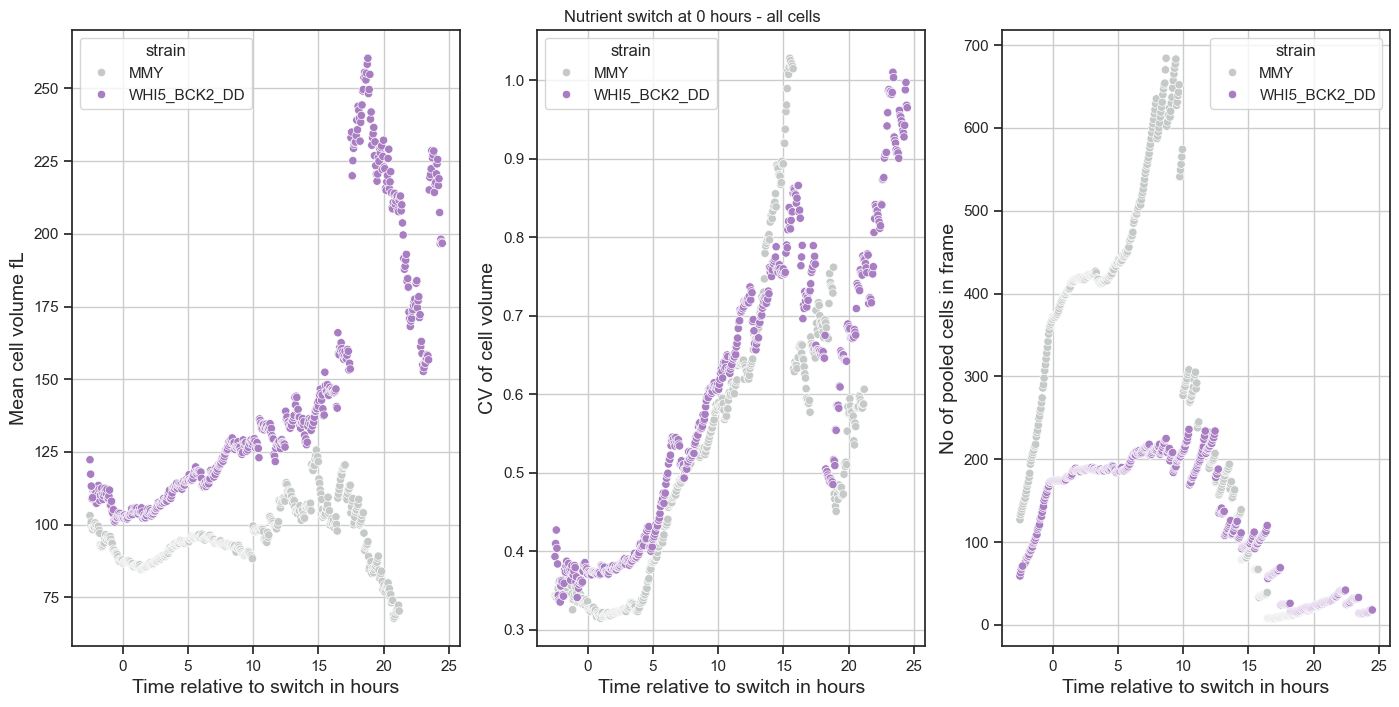

In [68]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

In [69]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1) & (select_strains_df["cell_cycle_stage"] == "G1")]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [70]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

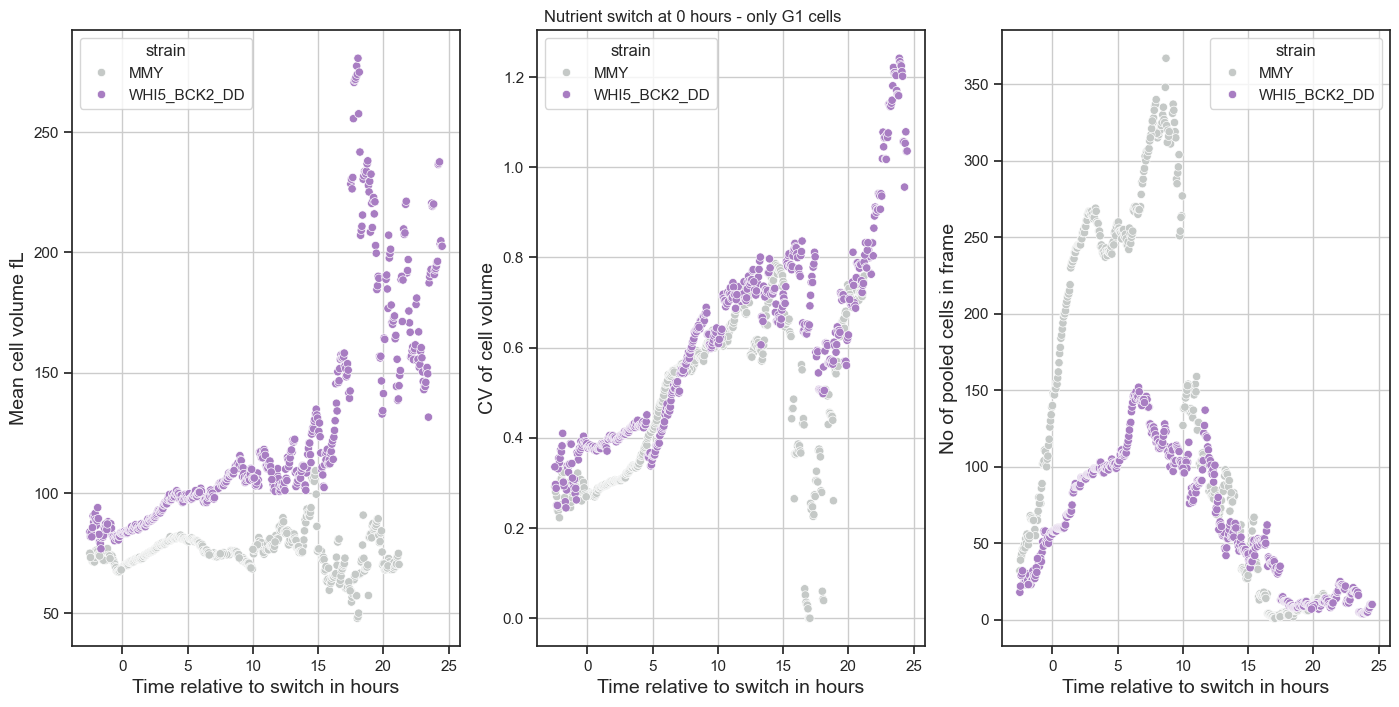

In [71]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - only G1 cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
plt.savefig(r'C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\post_switch_CVs_microscopy_onlyG1cells.svg')

In [72]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1) & (select_strains_df["cell_cycle_stage"] != "G1")]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [73]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

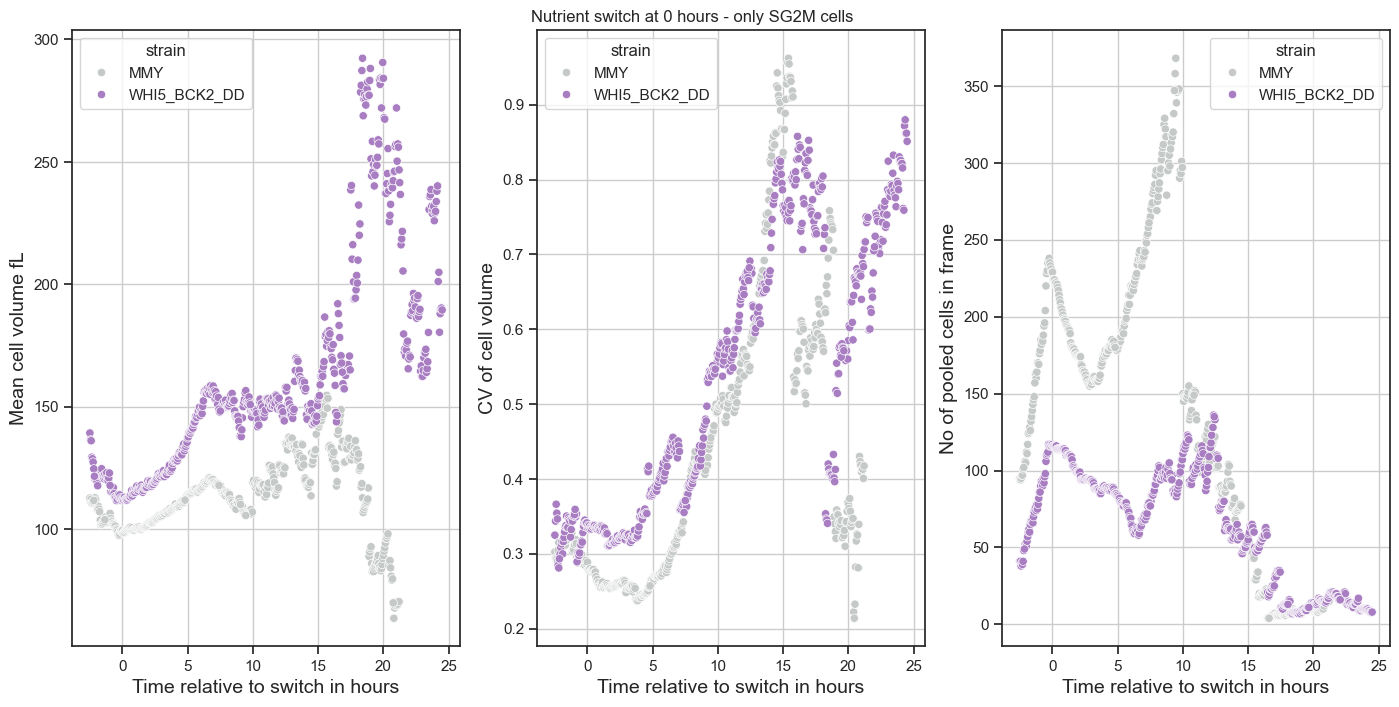

In [74]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - only SG2M cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_onlySG2Mcells')

# ***Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions OF A REP for every frame - REP 2 is an outlier*** 

In [75]:
#display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,cell_vol_fl_rel,combined_mother_bud_volume,f_pos_cell_id
0,0,1,0,S,135.471216,72.948291,208.419507,MMY_Position_1_Cell_1_Gen_2_Rep_1
1,1,1,0,S,131.569655,73.392645,204.962300,MMY_Position_1_Cell_1_Gen_2_Rep_1
2,2,1,0,G1,135.354415,76.026385,135.354415,MMY_Position_1_Cell_1_Gen_3_Rep_1
3,3,1,0,G1,136.988988,77.240173,136.988988,MMY_Position_1_Cell_1_Gen_3_Rep_1
4,4,1,0,G1,131.651731,76.639812,131.651731,MMY_Position_1_Cell_1_Gen_3_Rep_1
5,5,1,0,G1,131.117833,78.965256,131.117833,MMY_Position_1_Cell_1_Gen_3_Rep_1
6,6,1,0,G1,131.318354,82.143631,131.318354,MMY_Position_1_Cell_1_Gen_3_Rep_1
7,7,1,0,S,133.295539,0.881806,134.177345,MMY_Position_1_Cell_1_Gen_3_Rep_1
8,8,1,0,S,130.114343,2.567045,132.681388,MMY_Position_1_Cell_1_Gen_3_Rep_1
9,9,1,0,S,130.534535,3.559139,134.093674,MMY_Position_1_Cell_1_Gen_3_Rep_1


In [76]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []

import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [77]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,G1_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.812500,128.953785,198554.81,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.6520,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,135998.833293,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9.0,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,99.707260,38.147552,0.382596,57
315,110813,30,5400.0,2,0,0,521,459,0,G1,2.0,29.0,mother,-1.0,28.0,0.0,0.0,4063.0,30.470712,187137.187500,121.538473,187137.19,121.538473,1.0,0.0,429.0,430.0,31.0,399.0,1.081366,1049.240955,12108719.0,4263066.0,35075.856300,304,20220908,0,Position_29,Y:/Analysed Live cell microscopy data/20220908\Position_29\Images,5400.0,29.0,0.0,0.0,589.0,462.0,0.0,G1,1.0,2.0,mother,8.0,28.0,1.0,0.0,3064.0,22.978652,114754.531250,74.528695,114754.5300,74.528695,1.0,8.0,309.0,302.0,23.0,279.0,1.227728,845.247715,8506423.0,2589839.0,34749.554983,4263066.0,12108719.0,121.538473,0.944945,2.299572,29.233285,117.182958,119.482530,1.979884,4.389814,3,28.0,31.0,119.482530,1,1,3.0,3.0,WHI5_BCK2_DD,SCD,switch_gen,True,False,True,False,False,True,2.299572,NaN,NaN,0,2.0,28.0,117.182958,32.0,117.854963,197.0,348.706199,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,126.476970,50.986826,0.403131,42
685,155831,30,5400.0,1,0,0,409,261,0,S,1.0,10.0,mother,-1.0,15.0,0.0,0.0,3158.0,23.683610,123953.36

np.float64(99.70726047490743)

In [78]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

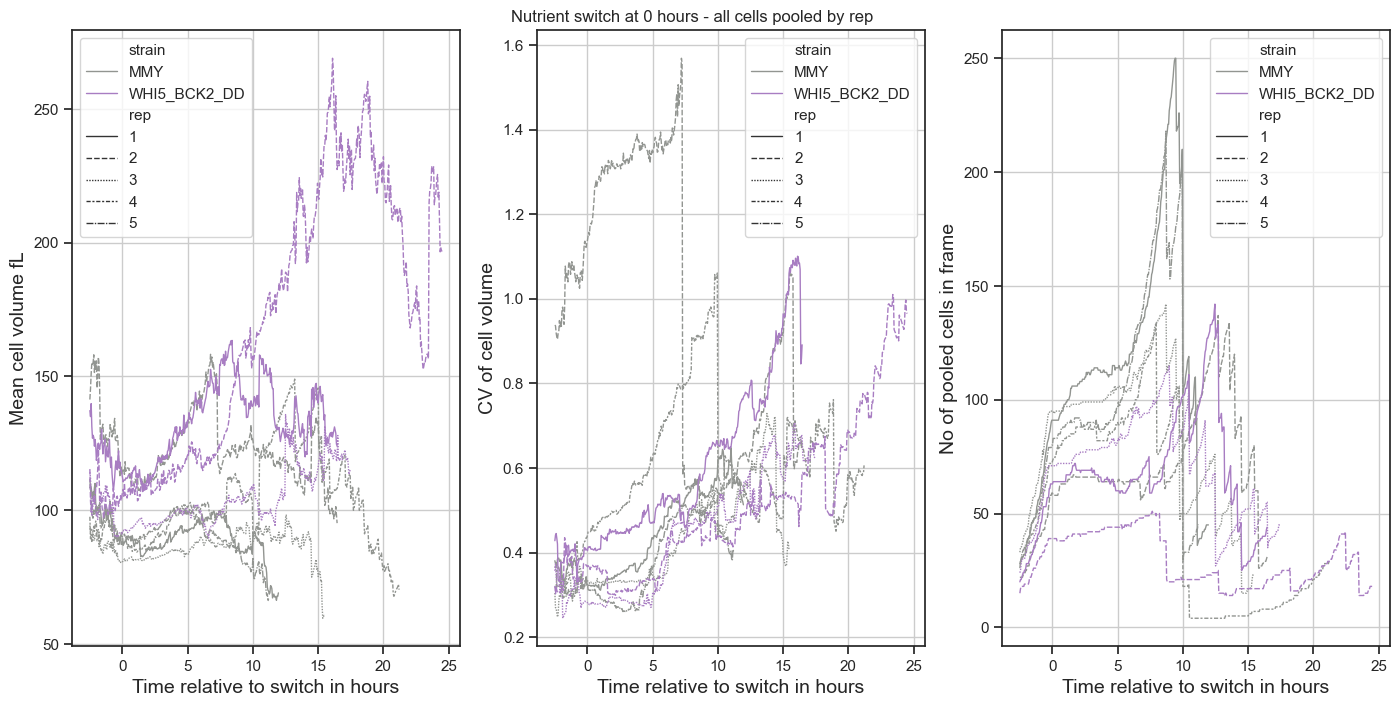

In [79]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                style = 'rep',
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                 style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                 style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

# ***Revision1: plotting frame-specific CVs after the nutrient switch by of each position of each rep - why is rep 2 an outlier*** 

In [80]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
# nobud_df = nobud_df.drop(nobud_df[(nobud_df['rep'] == 2)].index)
import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for pos in strain_df['position'].unique():
                pos_df  = strain_df[strain_df['position'] == pos]
                for frame in pos_df['frame_i'].unique():
                    frame_df = pos_df[pos_df['frame_i'] == frame]
                    frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                    frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                    frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                    frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                    # only append first row from frame_df to have only one row per frame in resulting df
                    j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [81]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['position'] == "Position_1")
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,G1_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.812500,128.953785,198554.810,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.65200,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,1.359988e+05,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9.0,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,112.684863,36.158300,0.320880,3
284,3329,30,5400.0,1,0,0,508,135,0,S,1.0,22.0,mother,-1.0,16.0,0.0,0.0,2574.0,19.303867,85314.734375,55.408669,85314.734,55.408669,1.0,0.0,279.0,280.0,31.0,249.0,1.319704,945.668998,8050620.0,2434152.0,43930.887307,244,20220908,0,Position_2,Y:/Analysed Live cell microscopy data/20220908\Position_2\Images,5400.0,22.0,0.0,0.0,486.0,159.0,0.0,S,0.0,1.0,bud,30.0,-1.0,1.0,0.0,64.0,0.479972,241.865768,0.157083,241.86577,0.157083,1.0,30.0,279.0,250.0,1.0,249.0,2.470045,3236.125000,346760.0,207112.0,1.318491e+06,2641264.0,8397380.0,55.565752,0.419975,1.418714,19.303867,55.408669,56.827383,14.346658,38.736567,40,30.0,70.0,95.721033,1,1,1.0,15.0,MMY,SCD,switch_gen,True,True,True,False,False,True,1.418714,NaN,NaN,1,14.0,16.0,40.503925,30.0,55.565752,70.0,95.721033,1,MMY_Position_2_Cell_1_Gen_1_Rep_1,-0.016993,-0.000306,0,nutrient_switch,84.182376,21.814078,0.259129,8
539,9485,30,5400.0,1,0,0,517,259,0,S,1.0,13.0,mother,-1.0,6.0,0.0,0.0,3152.0,23.638613,128655.953125,83.557139,128655.950,83.557139,1.0,0.0,251.0,

np.float64(112.68486332712853)

In [82]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\relational.py:733: UserWarning: relplot is a figure-level function and does not accept the `ax` parameter. You may wish to try scatterplot
  warnings.warn(msg, UserWarning)


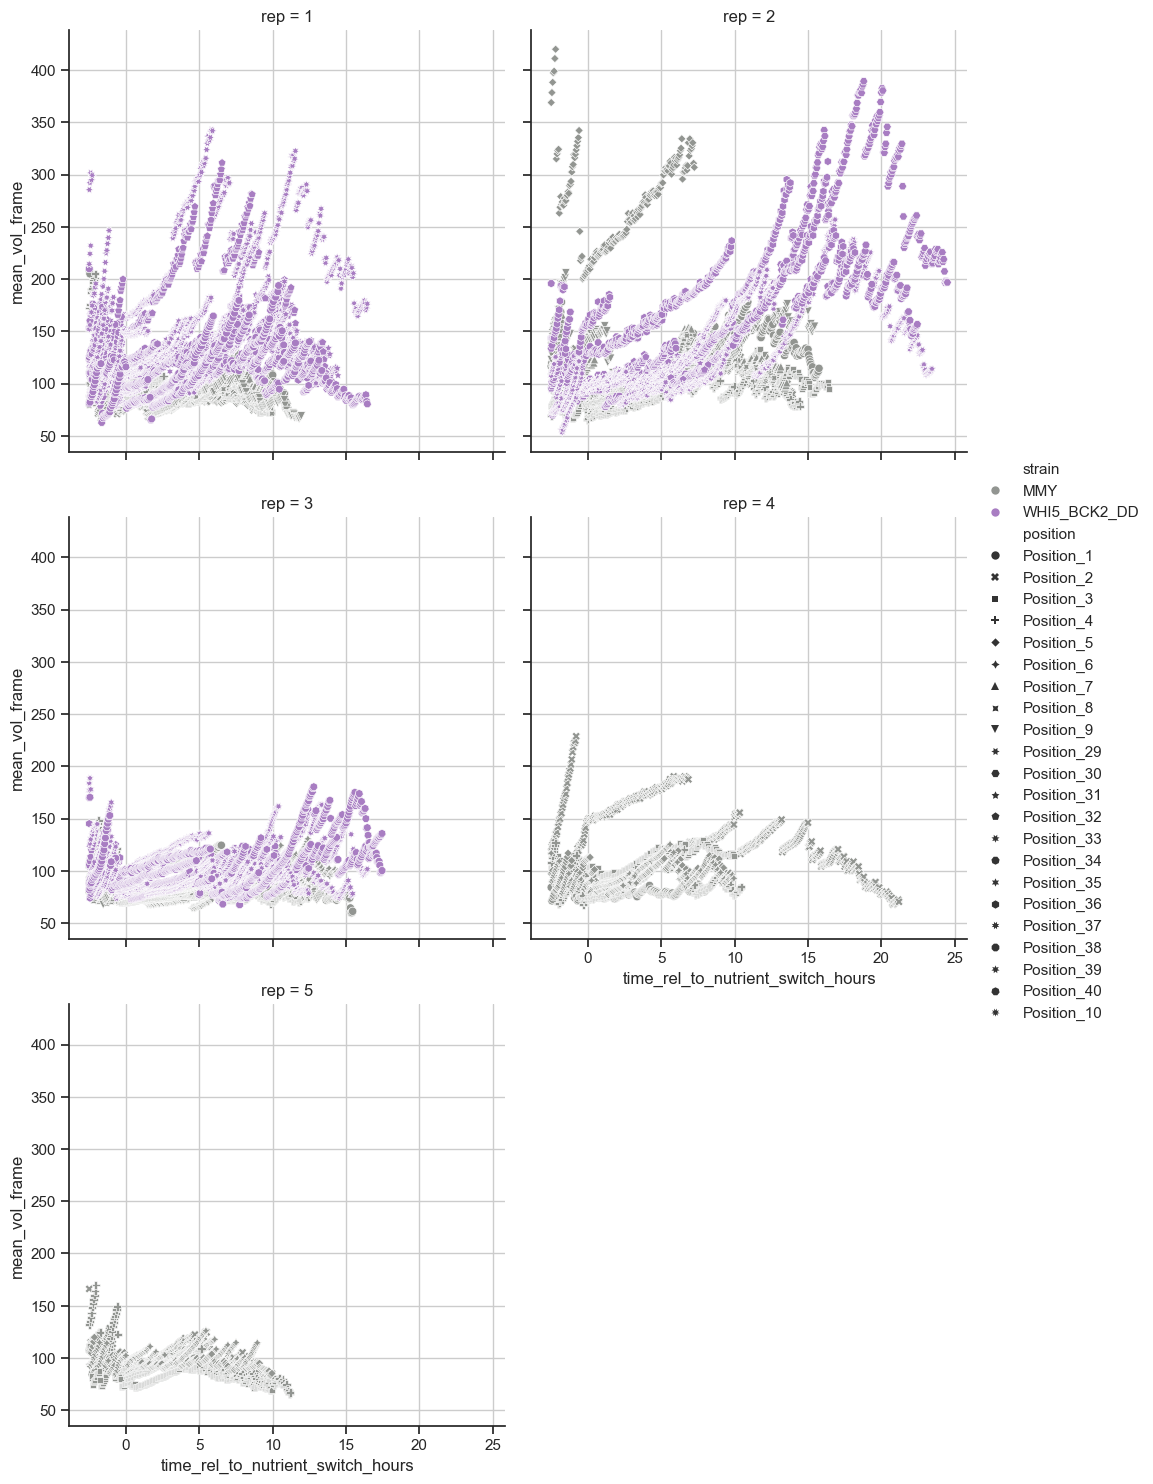

In [83]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
# S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x='time_rel_to_nutrient_switch_hours', 
#                 ax = ax1,
#                 y="mean_vol_frame", 
#                 hue = "strain", 
#                 style = 'pos',
#                 palette = palette
#                    )
S = sns.relplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="mean_vol_frame",
                style = 'position',
                col = 'rep',
                col_wrap = 2,
                hue = "strain", 
                palette = palette
                   )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x= 'time_rel_to_nutrient_switch_hours', 
#                 ax = ax3,
#                 y="n_cells_in_frame_pooled", 
#                 # style = 'rep',
#                 hue = "strain", 
#                 palette = palette
#                    )
# S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
# ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
# ax2.set_ylabel("CV of cell volume", fontsize = 14)
# ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\relational.py:733: UserWarning: relplot is a figure-level function and does not accept the `ax` parameter. You may wish to try scatterplot
  warnings.warn(msg, UserWarning)


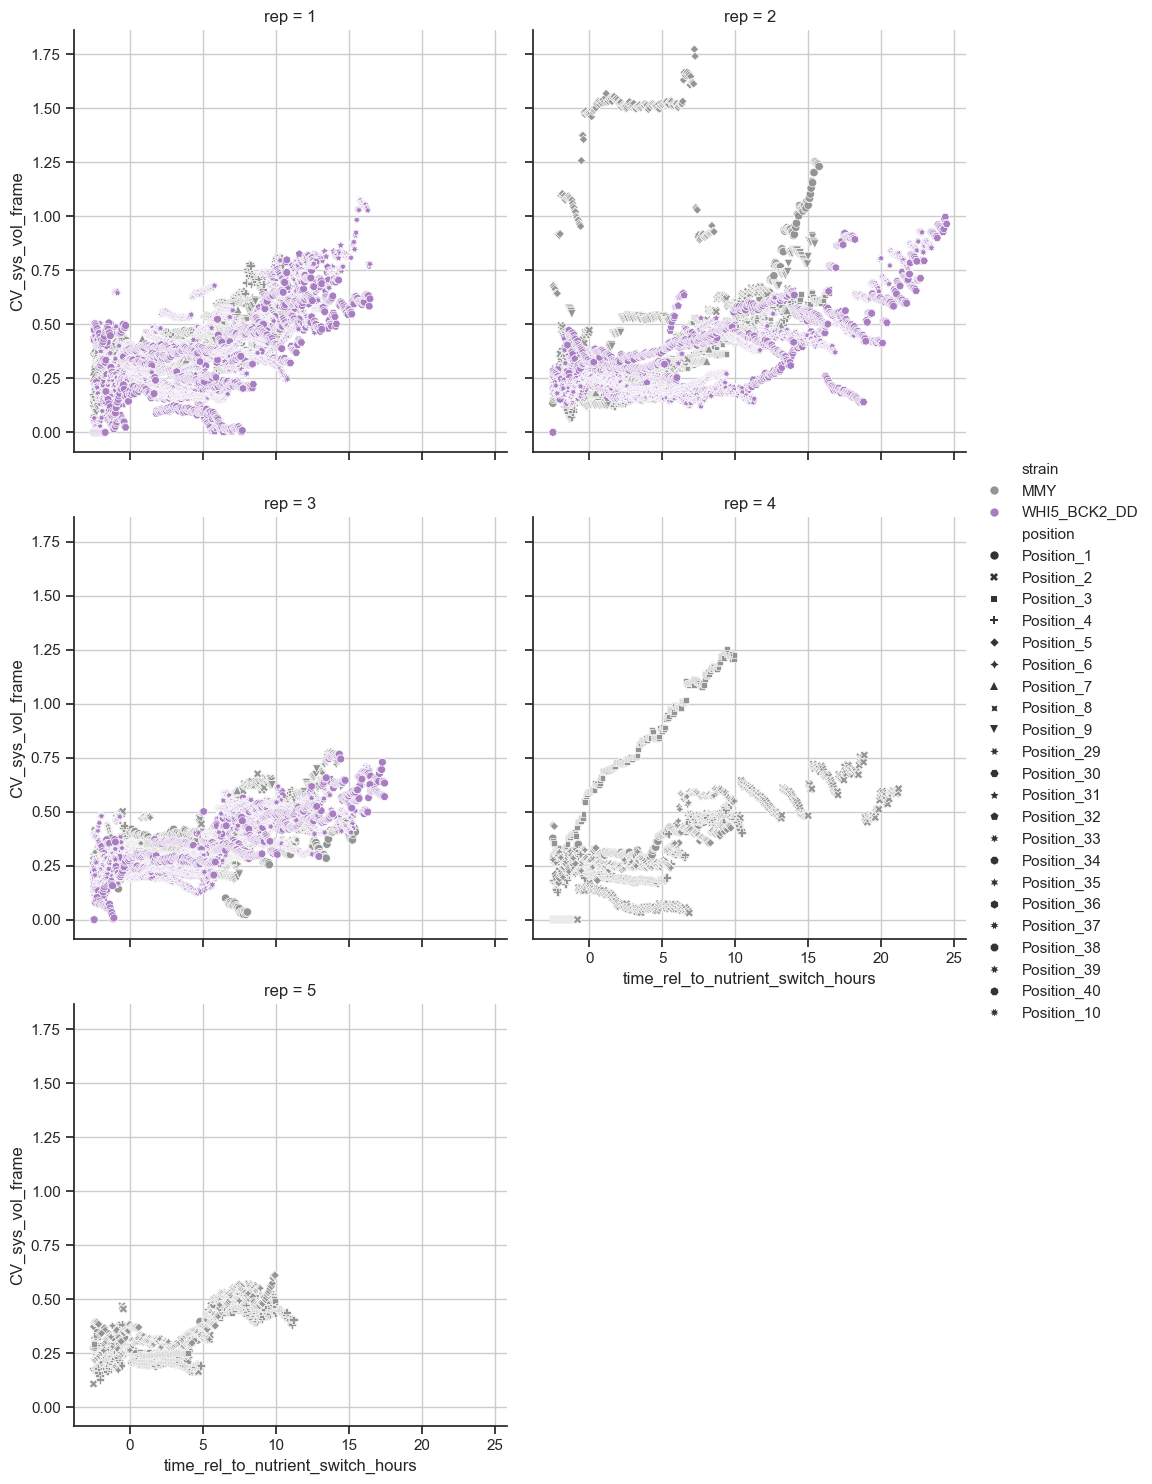

In [84]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
# S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x='time_rel_to_nutrient_switch_hours', 
#                 ax = ax1,
#                 y="mean_vol_frame", 
#                 hue = "strain", 
#                 style = 'pos',
#                 palette = palette
#                    )
S = sns.relplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                style = 'position',
                col = 'rep',
                col_wrap = 2,
                hue = "strain", 
                palette = palette
                   )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x= 'time_rel_to_nutrient_switch_hours', 
#                 ax = ax3,
#                 y="n_cells_in_frame_pooled", 
#                 # style = 'rep',
#                 hue = "strain", 
#                 palette = palette
#                    )
# S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
# ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
# ax2.set_ylabel("CV of cell volume", fontsize = 14)
# ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

In [85]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option('display.max_colwidth', None)
display(new_nobud_df_with_frame_specific_CVs[(new_nobud_df_with_frame_specific_CVs['rep'] == 4) &
                                            (new_nobud_df_with_frame_specific_CVs['position'] == "Position_3")])

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,G1_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled,frame_rel_to_nutrient_switch,time_rel_to_nutrient_switch_hours
18024,15189,0,0.0,1,0,0,606,53,0,S,2.0,2.0,mother,-1.0,-1.0,0.0,0.0,3849.0,28.865806,159440.156250,103.550306,159440.16,103.550306,1.0,0.0,299.0,300.0,1.0,299.0,1.265807,1529.531826,14455042.0,5887168.0,56853.216735,249,20230406,0,Position_3,Y:/Analysed Live cell microscopy data/20230406\Position_3\Images,0.0,2.0,0.0,0.0,618.0,106.0,0.0,S,0.0,1.0,bud,-1.0,-1.0,0.0,0.0,1743.0,13.071733,51090.953125,33.181627,51090.953,33.181627,1.0,0.0,299.0,300.0,1.0,299.0,1.166921,1979.825014,7330753.0,3450835.0,103998.365432,9338003.0,21785795.0,136.731933,0.817452,4.391093,28.865806,103.550306,107.941399,7.822041,36.473039,10,0.0,10.0,177.596066,0,0,1.0,1.0,MMY,SCD,NaN,False,False,True,False,False,True,4.391093,NaN,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,4,MMY_Position_3_Cell_1_Gen_2_Rep_4,NaN,NaN,0,nutrient_switch,102.776747,37.404495,0.363939,7,-50,-2.50
18025,15190,1,180.0,1,0,0,607,53,0,S,2.0,2.0,mother,-1.0,-1.0,0.0,0.0,3865.0,28.985799,160164.500000,104.020740,160164.50,104.020740,1.0,0.0,299.0,300.0,2.0,298.0,1.269563,1314.667012,12961923.0,5081188.0,48847.835612,249,20230406,0,Position_3,Y:/Analysed Live cell microscopy data/20230406\Position_3\Images,180.0,2.0,0.0,0.0,619.0,108.0,0.0,S,0.0,1.0,bud,-1.0,-1.0,0.0,0.0,1894.0,14.204167,57782.652344,37.527631,57782.652,37.527631,1.0,0.0,299.0,300.0,2.0,298.0,1.170883,1757.498944,7190569.0,3328703.0,88700.056891,8409891.0,20152492.0,141.548371,0.817452,4.391093,28.865806,103.550306,107.941399,7.822041,36.473039,10,0.0,10.0,177.596066,0,0,2.0,2.0,MMY,SCD,NaN,False,False,True,False,False,True,4.391093,NaN,NaN,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,4,MMY_Position_3_Cell_1_Gen_2_Rep_4,4.816437,0.034027,0,nutrient_switch,105.023600,36.910589,0.351450,7,-49,-2.45
18026,15191,2,360.0,1,0,0,606,53,0,S,2.0,2.0,mother,-1.0,-1.0,0.0,0.0,3823.0,28.670818,157569.500000,102.335386,15

# ***Revision1: we found two strong outlier positions in terms of CV of cell volume from previous cell: rep4 pos3 and rep2 pos5. The outlier behaviour comes from very large (8-10 micron) cells in these positions, so the large CV is real. Also, cell number is low.*** 

# ***Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions OF A REP for every frame - without the two outlier positions*** 

In [86]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [87]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,G1_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.812500,128.953785,198554.81,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.6520,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,135998.833293,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9.0,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,99.707260,38.147552,0.382596,57
315,110813,30,5400.0,2,0,0,521,459,0,G1,2.0,29.0,mother,-1.0,28.0,0.0,0.0,4063.0,30.470712,187137.187500,121.538473,187137.19,121.538473,1.0,0.0,429.0,430.0,31.0,399.0,1.081366,1049.240955,12108719.0,4263066.0,35075.856300,304,20220908,0,Position_29,Y:/Analysed Live cell microscopy data/20220908\Position_29\Images,5400.0,29.0,0.0,0.0,589.0,462.0,0.0,G1,1.0,2.0,mother,8.0,28.0,1.0,0.0,3064.0,22.978652,114754.531250,74.528695,114754.5300,74.528695,1.0,8.0,309.0,302.0,23.0,279.0,1.227728,845.247715,8506423.0,2589839.0,34749.554983,4263066.0,12108719.0,121.538473,0.944945,2.299572,29.233285,117.182958,119.482530,1.979884,4.389814,3,28.0,31.0,119.482530,1,1,3.0,3.0,WHI5_BCK2_DD,SCD,switch_gen,True,False,True,False,False,True,2.299572,NaN,NaN,0,2.0,28.0,117.182958,32.0,117.854963,197.0,348.706199,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,126.476970,50.986826,0.403131,42
685,155831,30,5400.0,1,0,0,409,261,0,S,1.0,10.0,mother,-1.0,15.0,0.0,0.0,3158.0,23.683610,123953.36

np.float64(99.70726047490743)

In [88]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

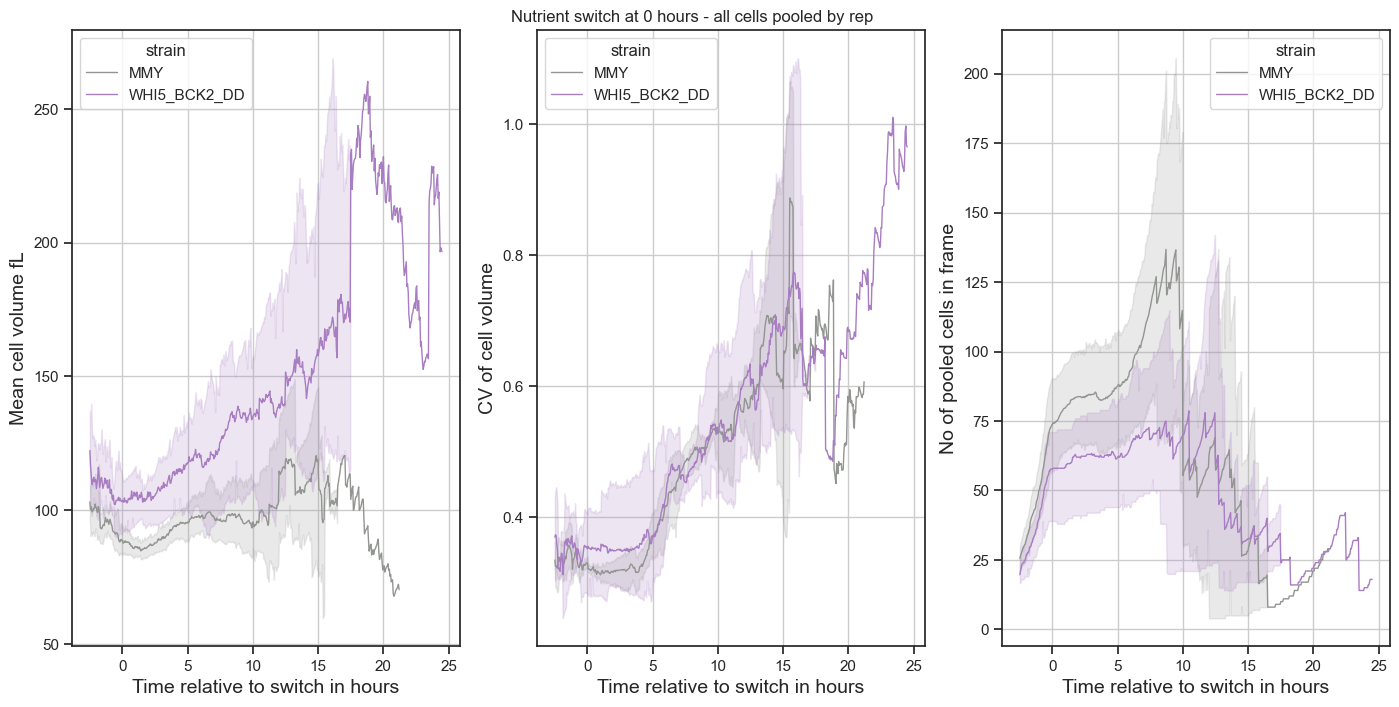

In [89]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                #style = 'rep',
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                # style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                # style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_repwiseCVs_microscopy_allcells_outlierPosRemoved')

# ***Revision1: calculating and plotting steady state frame-specific cell vol CVs for both media*** 

In [90]:
#calculating and plotting steady state frame-specific cell vol CVs for both media

In [91]:
display(SS_SCDnSCGE.columns.tolist())
select_strains_df = SS_SCDnSCGE[(SS_SCDnSCGE['strain'] == "MMY")|
                                (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'rel_vol_atframe', 'sys_vol_atframe','sys_vol_at_frame_inc_G1_cells', 'f_pos_cell_id', 'relationship', 'generation_num']].head(30))

['Unnamed: 0.2',
 'Unnamed: 0.1',
 'Unnamed: 0',
 'generation_num',
 'position',
 'Cell_ID',
 'growthmedium',
 'frame_i',
 'cell_cycle_stage',
 'relative_ID',
 'relationship',
 'cell_vol_fl',
 'emerg_frame_i',
 'division_frame_i',
 'len_G1',
 'rep',
 'strain',
 'Birth frame',
 'Birth vol fl',
 'last_G1_frame',
 'size_G1_end',
 'vol_added_G1',
 'Div frame',
 'Div vol fl',
 'len_S',
 'mother_size_emerg',
 'mother_size_div',
 'vol_added_S_mother',
 'bud_size_emerg',
 'bud_size_div',
 'vol_added_S_bud',
 'sys_size_emerg',
 'sys_size_div',
 'vol_added_S_tot',
 'total vol added',
 'time_seconds',
 'is_cell_dead',
 'complete_phase',
 'lenG1_mins',
 'G1_growthrate_flpermin',
 'delta_vol_fl',
 'delta_time_mins',
 'abs_growth_rate',
 'Birth_or_div_vol_fl',
 'rel_vol_atframe',
 'sys_vol_atframe',
 'delta_vol_sincePhaseStart_mother',
 'delta_vol_sincePhaseStart_sys',
 'norm_delta_vol_sincePhaseStart_mother',
 'norm_delta_vol_sincePhaseStart_sys',
 'bud_vol_atframe/mother_vol_atframe',
 'delta_vol_

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,rel_vol_atframe,sys_vol_atframe,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,relationship,generation_num
0,0,1,0,S,58.256695,92.927348,151.184043,151.184043,SCD_MMY_Position_1_Cell_1_Gen_0_Date_20012021,bud,0.0
1,1,1,0,S,60.404339,93.706004,154.110342,154.110342,SCD_MMY_Position_1_Cell_1_Gen_0_Date_20012021,bud,0.0
2,2,1,0,S,61.139191,94.112864,155.252054,155.252054,SCD_MMY_Position_1_Cell_1_Gen_0_Date_20012021,bud,0.0
3,3,1,0,S,62.500215,95.679685,158.179900,158.179900,SCD_MMY_Position_1_Cell_1_Gen_0_Date_20012021,bud,0.0
4,4,1,0,S,63.211776,97.265445,160.477221,160.477221,SCD_MMY_Position_1_Cell_1_Gen_0_Date_20012021,bud,0.0
5,5,1,0,S,63.341337,99.942398,163.283735,163.283735,SCD_MMY_Position_1_Cell_1_Gen_0_Date_20012021,bud,0.0
6,6,1,0,S,64.975784,102.084921,167.060705,167.060705,SCD_MMY_Position_1_Cell_1_Gen_0_Date_20012021,bud,0.0
7,7,1,0,G1,67.499547,NaN,NaN,67.499547,SCD_MMY_Position_1_Cell_1_Gen_1_Date_20012021,mother,1.0
8,8,1,0,G1,67.411987,NaN,NaN,67.411987,SCD_MMY_Position_1_Cell_1_Gen_1_Date_20012021,mother,1.0
9,9,1,0,G1,68.835553,NaN,NaN,68.835553,SCD_MMY_Position_1_Cell_1_Gen_1_Date_20012021,mother,1.0


In [92]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []

import warnings
with warnings.catch_warnings(record=True):
    for medium in nobud_df['growthmedium'].unique():
        medium_df  = nobud_df[nobud_df['growthmedium'] == medium]
        for strain in medium_df['strain'].unique():
            strain_df  = medium_df[medium_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["sys_vol_at_frame_inc_G1_cells"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["sys_vol_at_frame_inc_G1_cells"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [93]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 1])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['growthmedium'] == "SCD")
                            & (select_strains_df['frame_i'] == 1)]
display(test_df.sys_vol_at_frame_inc_G1_cells.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,generation_num,position,Cell_ID,growthmedium,frame_i,cell_cycle_stage,relative_ID,relationship,cell_vol_fl,emerg_frame_i,division_frame_i,len_G1,rep,strain,Birth frame,Birth vol fl,last_G1_frame,size_G1_end,vol_added_G1,Div frame,Div vol fl,len_S,mother_size_emerg,mother_size_div,vol_added_S_mother,bud_size_emerg,bud_size_div,vol_added_S_bud,sys_size_emerg,sys_size_div,vol_added_S_tot,total vol added,time_seconds,is_cell_dead,complete_phase,lenG1_mins,G1_growthrate_flpermin,delta_vol_fl,delta_time_mins,abs_growth_rate,Birth_or_div_vol_fl,rel_vol_atframe,sys_vol_atframe,delta_vol_sincePhaseStart_mother,delta_vol_sincePhaseStart_sys,norm_delta_vol_sincePhaseStart_mother,norm_delta_vol_sincePhaseStart_sys,bud_vol_atframe/mother_vol_atframe,delta_vol_sinceG1Start,norm_delta_vol_sinceG1Start,Daughterhood_binary,time_in_stage_mins,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,complete_cycle,frames_since_cycle_start,vol_added_since_last_frame,delta_vol_norm_cellvol,experiment_type,alpha,alpha_G1_length_frames,ln_birth_or_div_vol,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
87,271,271,271.0,2.0,Position_1,4,SCD,1,S,1.0,mother,93.706004,-1.0,-1.0,NaN,20012021,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,74.133357,18,4.118520,NaN,60.404339,154.110342,NaN,NaN,NaN,NaN,0.644615,NaN,NaN,0,3.0,154.110342,SCD_MMY_Position_1_Cell_4_Gen_2_Date_20012021,0.0,1.0,2.926300,0.018988,steady state,NaN,NaN,NaN,82.616140,33.454366,0.404937,64
181,25699,25699,25699.0,2.0,Position_20,2,SCD,1,S,5.0,mother,131.495677,-1.0,-1.0,NaN,20012021,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,57.152393,188.648071,NaN,NaN,NaN,NaN,0.434633,NaN,NaN,0,3.0,188.648071,SCD_WHI5_BCK2_DD_Position_20_Cell_2_Gen_2_Date_20012021,0.0,1.0,3.013392,0.015974,steady state,NaN,NaN,NaN,96.968070,37.899369,0.390844,70
213,121010,121010,121010.0,2.0,Position_1,1,SCGE,1,G1,-1.0,mother,56.028432,-1.0,-1.0,NaN,23092021,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,96.991980,210,0.461867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,56.028432,SCGE_MMY_Position_1_Cell_1_Gen_2_Date_23092021,0.0,1.0,0.152537,0.002722,steady state,NaN,NaN,NaN,66.320359,32.439308,0.489130,47
513,189839,189839,189839.0,2.0,Position_29,1,SCGE,1,S,6.0,mother,117.399729,-1.0,-1.0,NaN,23092021,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,11.244754,128.644483,NaN,NaN,NaN,NaN,0.095782,NaN,NaN,0,3.0,128.644483,SCGE_WHI5_BCK2_DD_Position_29_Cell_1_Gen_2_Date_23092021,0.0,1.0,-0.523383,-0.004068,steady state,NaN,NaN,NaN,87.733620,47.059441,0.536390,41


np.float64(82.61613960086679)

In [94]:
new_nobud_df_with_frame_specific_CVs['time_in_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_i']*3)/60
new_nobud_df_with_frame_specific_CVs.sort_values(by = 'frame_i', inplace = True)
display(new_nobud_df_with_frame_specific_CVs.head(20))

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,generation_num,position,Cell_ID,growthmedium,frame_i,cell_cycle_stage,relative_ID,relationship,cell_vol_fl,emerg_frame_i,division_frame_i,len_G1,rep,strain,Birth frame,Birth vol fl,last_G1_frame,size_G1_end,vol_added_G1,Div frame,Div vol fl,len_S,mother_size_emerg,mother_size_div,vol_added_S_mother,bud_size_emerg,bud_size_div,vol_added_S_bud,sys_size_emerg,sys_size_div,vol_added_S_tot,total vol added,time_seconds,is_cell_dead,complete_phase,lenG1_mins,G1_growthrate_flpermin,delta_vol_fl,delta_time_mins,abs_growth_rate,Birth_or_div_vol_fl,rel_vol_atframe,sys_vol_atframe,delta_vol_sincePhaseStart_mother,delta_vol_sincePhaseStart_sys,norm_delta_vol_sincePhaseStart_mother,norm_delta_vol_sincePhaseStart_sys,bud_vol_atframe/mother_vol_atframe,delta_vol_sinceG1Start,norm_delta_vol_sinceG1Start,Daughterhood_binary,time_in_stage_mins,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,complete_cycle,frames_since_cycle_start,vol_added_since_last_frame,delta_vol_norm_cellvol,experiment_type,alpha,alpha_G1_length_frames,ln_birth_or_div_vol,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled,time_in_hours
86,270,270,270.0,2.0,Position_1,4,SCD,0,S,1.0,mother,92.927348,-1.0,-1.0,NaN,20012021,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,74.133357,18,4.118520,NaN,58.256695,151.184043,NaN,NaN,NaN,NaN,0.626906,NaN,NaN,0,0.0,151.184043,SCD_MMY_Position_1_Cell_4_Gen_2_Date_20012021,0.0,0.0,NaN,NaN,steady state,NaN,NaN,NaN,83.377499,32.550240,0.390396,61,0.00
512,189838,189838,189838.0,2.0,Position_29,1,SCGE,0,S,6.0,mother,118.315411,-1.0,-1.0,NaN,23092021,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,10.852455,129.167866,NaN,NaN,NaN,NaN,0.091725,NaN,NaN,0,0.0,129.167866,SCGE_WHI5_BCK2_DD_Position_29_Cell_1_Gen_2_Date_23092021,0.0,0.0,NaN,NaN,steady state,NaN,NaN,NaN,91.507627,50.812218,0.555279,39,0.00
212,121009,121009,121009.0,2.0,Position_1,1,SCGE,0,G1,-1.0,mother,55.875895,-1.0,-1.0,NaN,23092021,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,96.991980,210,0.461867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,55.875895,SCGE_MMY_Position_1_Cell_1_Gen_2_Date_23092021,0.0,0.0,NaN,NaN,steady state,NaN,NaN,NaN,73.937696,35.026017,0.473723,42,0.00
180,25698,25698,25698.0,2.0,Position_20,2,SCD,0,S,5.0,mother,131.888886,-1.0,-1.0,NaN,20012021,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,53.745793,185.634679,NaN,NaN,NaN,NaN,0.407508,NaN,NaN,0,0.0,185.634679,SCD_WHI5_BCK2_DD_Position_20_Cell_2_Gen_2_Date_20012021,0.0,0.0,NaN,NaN,steady state,NaN,NaN,NaN,98.457389,37.422897,0.380092,67,0.00
181,25699,25699,25699.0,2.0,Position_20,2,SCD,1,S,5.0,mother,131.495677,-1.0,-1.0,NaN,20012021,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,57.152393,188.648071,NaN,NaN,NaN,NaN,0.434633,NaN,NaN,0,3.0,188.648071,SCD_WHI5_BCK2_DD_Position_20_Cell_2_Gen_2_Date_20012021,0.0,1.0,3.013392,0.015974,steady state,NaN,NaN,NaN,96.968070,37.899369,0.390844,70,0.05
87,271,271,271.0,2.0,Position_1,4,SCD,1,S,1.0,mother,93.706004,-1.0,-1.0,NaN,20012021,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,74.133357,18,4.118520,NaN,60.404339,154.110342,NaN,NaN,NaN,NaN,0.644615,NaN,NaN,0,3.0,154.110342,SCD_MMY_Position_1_Cell_4_Gen_2_Date_20012021,0.0,1.0,2.926300,0.018988,steady state,NaN,NaN,NaN,82.616140,33.454366,0.404937,64,0.05
513,189839,189839,189839.0,2.0,Position_29,1,SCGE,1,S,6.0,mother,117.399729,-1.0,-1.0,NaN,23092021,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,11.244754,128.644483,NaN,NaN,NaN,NaN,0.095782,NaN,NaN,0,3.0,128.644483,SCGE_WHI5_

Text(0, 0.5, 'No of pooled cells in frame')

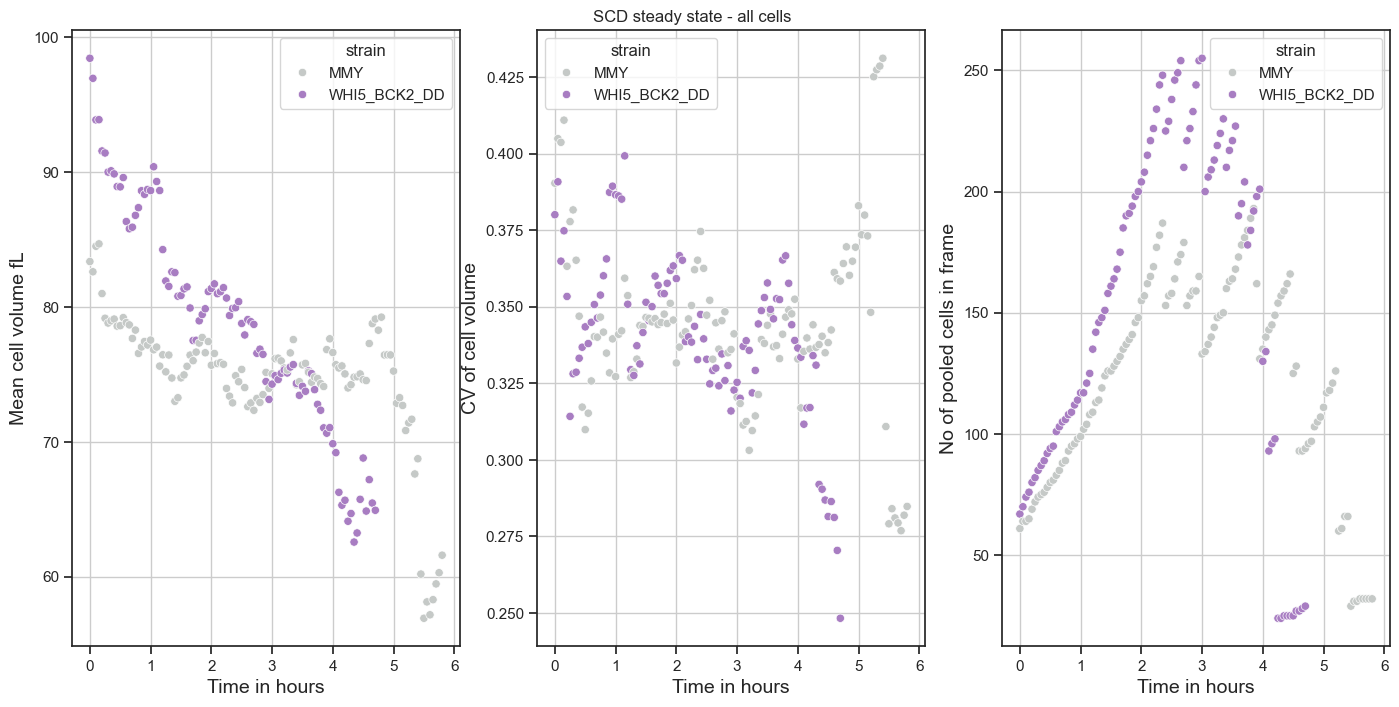

In [95]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x='time_in_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x= 'time_in_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x= 'time_in_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("SCD steady state - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time in hours", fontsize = 14)
ax2.set_xlabel("Time in hours", fontsize = 14)
ax3.set_xlabel("Time in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

Text(0, 0.5, 'No of pooled cells in frame')

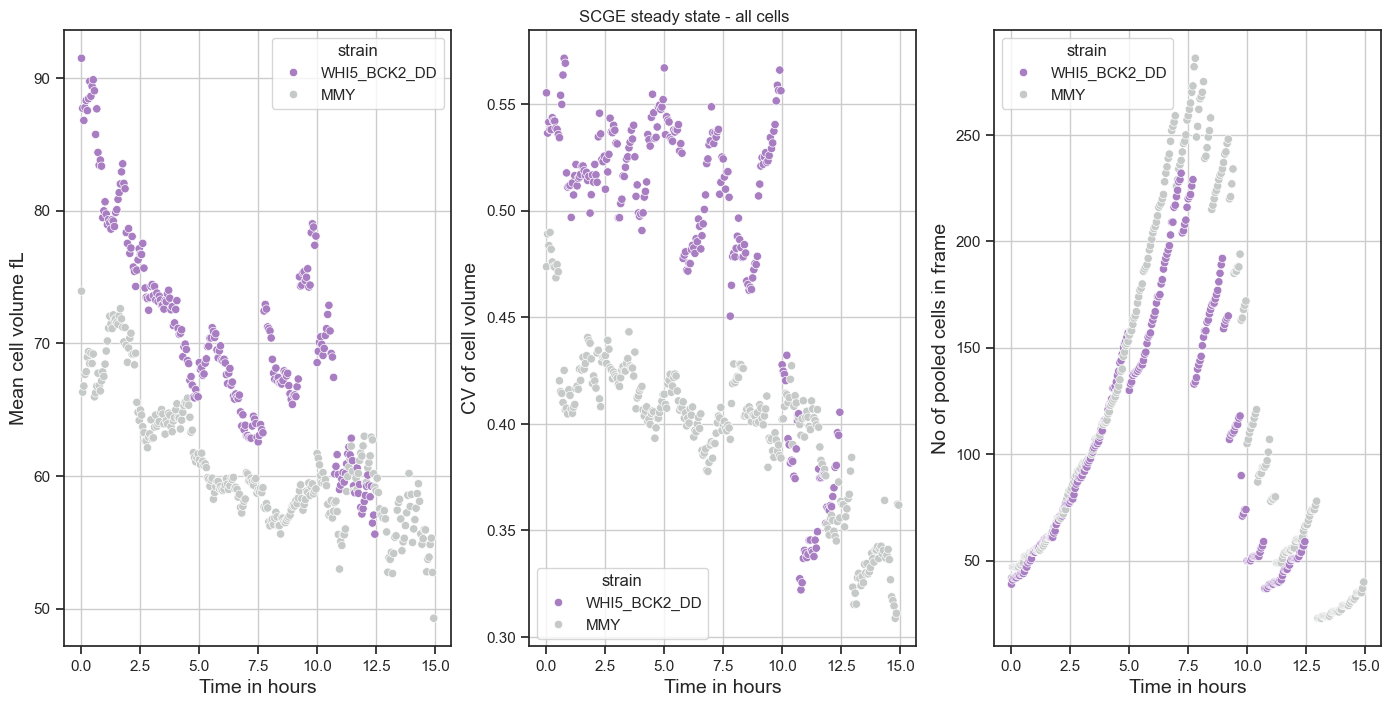

In [96]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x='time_in_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x= 'time_in_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x= 'time_in_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("SCGE steady state - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time in hours", fontsize = 14)
ax2.set_xlabel("Time in hours", fontsize = 14)
ax3.set_xlabel("Time in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')